# Importation et inspection des données

In [1]:
import pandas as pd
import sqlite3 as sql
import numpy as np
import matplotlib.pyplot as plt

#installation à la volée du package (éventuellement)
#!pip install fanalysis
from fanalysis.mca import MCA 



## Ajout de correctifs dans les fonctions de graphique

In [2]:


def custom_mapping(self, num_x_axis, num_y_axis, short_labels=True, 
                   ax=None, figsize=None):
    """ Plot the Factor map for rows and columns simultaneously on given ax """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    if self.model_ == "mca" and short_labels:
        col_labels = self.col_labels_short_
    else:
        col_labels = self.col_labels_

    # Plot row points (invisible scatter, just for scaling)
    ax.scatter(self.row_coord_[:, num_x_axis - 1],
               self.row_coord_[:, num_y_axis - 1],
               marker=".", color="white", zorder=0)

    # Plot column points (invisible scatter)
    ax.scatter(self.col_coord_[:, num_x_axis - 1],
               self.col_coord_[:, num_y_axis - 1],
               marker=".", color="white", zorder=0)

    # Add row labels
    for i in np.arange(0, self.row_coord_.shape[0]):
        ax.text(self.row_coord_[i, num_x_axis - 1],
                self.row_coord_[i, num_y_axis - 1],
                self.row_labels_[i],
                horizontalalignment="center", verticalalignment="center",
                color="red", zorder=5)

    # Add column labels
    for i in np.arange(0, self.col_coord_.shape[0]):
        ax.text(self.col_coord_[i, num_x_axis - 1],
                self.col_coord_[i, num_y_axis - 1],
                col_labels[i],
                horizontalalignment="center", verticalalignment="center",
                color="blue", zorder=5)

    ax.set_title("Factor map")
    ax.set_xlabel("Dim " + str(num_x_axis) + " ("
                  + str(np.around(self.eig_[1, num_x_axis - 1], 2)) + "%)")
    ax.set_ylabel("Dim " + str(num_y_axis) + " ("
                  + str(np.around(self.eig_[1, num_y_axis - 1], 2)) + "%)")
    ax.axvline(x=0, linestyle="--", linewidth=0.5, color="k", zorder=0)
    ax.axhline(y=0, linestyle="--", linewidth=0.5, color="k", zorder=0)

    return ax  # return ax for further customization



# Monkey-patch: on remplace la fonction de la bibliothèque par celle-ci
MCA.mapping = custom_mapping


In [3]:
def custom_mapping_col(self, num_x_axis, num_y_axis, short_labels=True,
                    ax=None, figsize=None):
        """ Plot the Factor map for columns only
        
        """

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig = ax.get_figure()

        if self.model_ == "mca" and short_labels:
            col_labels = self.col_labels_short_
        else:
            col_labels = self.col_labels_
        
        ax.scatter(self.col_coord_[:, num_x_axis - 1],
                    self.col_coord_[:, num_y_axis - 1],
                    marker=".", color="white")
        for i in np.arange(0, self.col_coord_.shape[0]):
            ax.text(self.col_coord_[i, num_x_axis - 1],
                     self.col_coord_[i, num_y_axis - 1],
                     col_labels[i],
                     horizontalalignment="center", verticalalignment="center",
                     color="blue")
        ax.set_title("Factor map for columns")
        ax.set_xlabel("Dim " + str(num_x_axis) + " ("
                    + str(np.around(self.eig_[1, num_x_axis - 1], 2)) + "%)")
        ax.set_ylabel("Dim " + str(num_y_axis) + " ("
                    + str(np.around(self.eig_[1, num_y_axis - 1], 2)) + "%)")
        ax.axvline(x=0, linestyle="--", linewidth=0.5, color="k")
        ax.axhline(y=0, linestyle="--", linewidth=0.5, color="k")
        
        return ax 

# Monkey-patch: on remplace la fonction de la bibliothèque par celle-ci
MCA.mapping_col = custom_mapping_col

In [4]:
def custom_plot_eigenvalues(self, type="absolute", ax=None, figsize=None):
        """ Plot the eigen values graph
        
        Parameters
        ----------
        type : string
            Select the graph to plot :
                - If "absolute" : plot the eigenvalues.
                - If "percentage" : plot the percentage of variance.
                - If "cumulative" : plot the cumulative percentage of
                  variance.
        figsize : tuple of integers or None
            Width, height of the figure in inches.
            If not provided, defaults to rc figure.figsize

        Returns
        -------
        None
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)

        if type == "absolute":
            ax.bar(np.arange(1, self.eig_[0].shape[0] + 1), self.eig_[0],
                    color="steelblue", align="center")
            ax.set_xlabel("Axis")
            ax.set_ylabel("Eigenvalue")
            ax.set_title("Scree plot: Eigenvalue")
        elif type == "percentage":
            ax.bar(np.arange(1, self.eig_[1].shape[0] + 1), self.eig_[1],
                    color="steelblue", align="center")
            ax.set_xlabel("Axis")
            ax.set_ylabel("Percentage of variance")
            ax.set_title("Scree plot: Percentage")
        elif type == "cumulative":
            ax.bar(np.arange(1, self.eig_[2].shape[0] + 1), self.eig_[2],
                    color="steelblue", align="center")
            ax.set_xlabel("Axis")
            ax.set_ylabel("Cumulative percentage of variance")
            ax.set_title("Scree plot: Cumulative")
        else:
            raise ValueError("Error : 'type' variable must be 'absolute' or \
                            'percentage' or 'cumulative'")
        
        
        ax.grid(True, alpha=0.3)

# Monkey-patch: on remplace la fonction de la bibliothèque par celle-ci
MCA.plot_eigenvalues = custom_plot_eigenvalues

In [5]:
def custom_plot_row_contrib(self, num_axis, nb_values=None, ax=None, figsize=None):
        """ Plot the eigen values graph
        
        Parameters
        ----------
        type : string
            Select the graph to plot :
                - If "absolute" : plot the eigenvalues.
                - If "percentage" : plot the percentage of variance.
                - If "cumulative" : plot the cumulative percentage of
                  variance.
        figsize : tuple of integers or None
            Width, height of the figure in inches.
            If not provided, defaults to rc figure.figsize

        Returns
        -------
        None
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)

        n_rows = len(self.row_labels_)
        n_labels = len(self.row_labels_)
        if (nb_values is not None) and (nb_values < n_labels):
            n_labels = nb_values
        limit = n_rows - n_labels
        contribs = self.row_contrib_[:, num_axis - 1]
        contribs_sorted = np.sort(contribs)[limit:n_rows]
        labels = pd.Series(self.row_labels_)[np.argsort(contribs)]\
                                                        [limit:n_rows]
        r = range(n_labels)
        bar_width = 0.5
        ax.set_yticks([ri + bar_width / 2 for ri in r], labels)
        ax.barh(r, contribs_sorted, height=bar_width, color="steelblue",
                 align="edge")
        ax.set_title("Rows contributions")
        ax.set_xlabel("Contributions (%)")
        ax.set_ylabel("Rows")
        
        ax.grid(True, alpha=0.3)

# Monkey-patch: on remplace la fonction de la bibliothèque par celle-ci
MCA.plot_row_contrib = custom_plot_row_contrib

In [6]:
def custom_plot_col_contrib(self, num_axis, nb_values=None, ax=None, 
                            short_labels=True, figsize=None):
        """ Plot the eigen values graph
        
        Parameters
        ----------
        type : string
            Select the graph to plot :
                - If "absolute" : plot the eigenvalues.
                - If "percentage" : plot the percentage of variance.
                - If "cumulative" : plot the cumulative percentage of
                  variance.
        figsize : tuple of integers or None
            Width, height of the figure in inches.
            If not provided, defaults to rc figure.figsize

        Returns
        -------
        None
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)

        n_cols = len(self.col_labels_)
        n_labels = len(self.col_labels_)
        if self.model_ == "mca" and short_labels:
            col_labels = self.col_labels_short_
        else:
            col_labels = self.col_labels_
        if (nb_values is not None) and (nb_values < n_labels):
            n_labels = nb_values
        limit = n_cols - n_labels
        contribs = self.col_contrib_[:, num_axis - 1]
        contribs_sorted = np.sort(contribs)[limit:n_cols]
        labels = pd.Series(col_labels)[np.argsort(contribs)][limit:n_cols]
        r = range(n_labels)
        bar_width = 0.5
        ax.set_yticks([ri + bar_width / 2 for ri in r], labels)
        ax.barh(r, contribs_sorted, height=bar_width, color="steelblue",
                 align="edge")
        ax.set_title("Columns contributions")
        ax.set_xlabel("Contributions (%)")
        ax.set_ylabel("Columns")
        
        ax.grid(True, alpha=0.3)

# Monkey-patch: on remplace la fonction de la bibliothèque par celle-ci
MCA.plot_col_contrib = custom_plot_col_contrib

## Create a dataframe with the data to be analysed

In this notebook, we use the data produced with the [bivariate analysis notebook using countries](da3-1_countries_bivariate_analysis.ipynb) and the data collected in the [da5-employer.md](../../documentation/wikidata/data-analysis/da5-employer.md) and [da5-employer.sql](../../documentation/wikidata/data-analysis/da5-employer.sql) files.




In [7]:
csv_address='da_data/da4-AFC.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1827,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1834,1826-1850


In [8]:
df_p = df_p.drop(['CNTR_ID', 'CNTR_NAME', 'ISO3_CODE', 'activityYear', 'uriPlace', 'periods', 'FID', 'CNTR_ID'], axis=1)

In [9]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20043 entries, 0 to 20042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uriPer           20043 non-null  object
 1   labelPer         20043 non-null  object
 2   birthYear        20043 non-null  int64 
 3   gender           20043 non-null  object
 4   labelPlace       20043 non-null  object
 5   geometry         20043 non-null  object
 6   REGION           20043 non-null  object
 7   NAME_ENGL        20043 non-null  object
 8   coded_country    20043 non-null  object
 9   periodsActivity  20043 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.5+ MB


In [10]:
df_p=df_p.rename(columns={'uriPer': 'person_uri'})

In [11]:
df_p.head(1)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),Western Europe,France,France,1826-1850


In [12]:
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

In [13]:
csv_address='da_data/da5-persons-features.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
## df_pfeat = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None'])
df_pfeat = pd.read_csv(csv_address)
df_pfeat.head()

,pk_person_features,person_uri,occupation_main,occupation_sec1,coded_employer
0,2,http://www.wikidata.org/entity/Q1000934,physicist,university-teacher,education
1,3,http://www.wikidata.org/entity/Q100153910,physicist,university-teacher,education
2,5,http://www.wikidata.org/entity/Q100157315,physicist,university-teacher,university
3,8,http://www.wikidata.org/entity/Q100212,physicist,university-teacher,publisher
4,9,http://www.wikidata.org/entity/Q100216,physicist,university-teacher,institute


In [14]:
### Observe the 
df_pfeat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10900 entries, 0 to 10899
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pk_person_features  10900 non-null  int64 
 1   person_uri          10900 non-null  object
 2   occupation_main     10900 non-null  object
 3   occupation_sec1     10900 non-null  object
 4   coded_employer      10900 non-null  object
dtypes: int64(1), object(4)
memory usage: 425.9+ KB


In [15]:
df_pm = pd.merge(df_p,df_pfeat, on='person_uri')  
# following used for inspection
# , how='left')

In [16]:
## The small number depends on the considered countries
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7946 entries, 0 to 7945
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          7946 non-null   object
 1   labelPer            7946 non-null   object
 2   birthYear           7946 non-null   int64 
 3   gender              7946 non-null   object
 4   labelPlace          7946 non-null   object
 5   geometry            7946 non-null   object
 6   REGION              7946 non-null   object
 7   NAME_ENGL           7946 non-null   object
 8   coded_country       7946 non-null   object
 9   periodsActivity     7946 non-null   object
 10  pk_person_features  7946 non-null   int64 
 11  occupation_main     7946 non-null   object
 12  occupation_sec1     7946 non-null   object
 13  coded_employer      7946 non-null   object
dtypes: int64(2), object(12)
memory usage: 869.2+ KB


## Inspect distribution of variables

In [17]:
### Group and count: gender
# This variable creates a significant divide
df_count = df_pm.groupby('gender').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



        number
gender        
male      7369
female     577


In [18]:
### Group and count: main occupation
# This variable creates a significant divide
df_count = df_pm.groupby('occupation_main').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                 number
occupation_main        
physicist          6488
astronomer         1458


In [19]:
### Group and count: country
df_count = df_pm.groupby('coded_country').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                           number
coded_country                    
Germany                      1545
United States Can.           1402
Russian Federation            747
United Kingdom                524
France                        423
Poland                        394
Italy                         387
Austria Hungary               314
Belgium Netherl.              291
Ukraine                       273
Baltic States Fin. Belar.     236
Czechia                       224
Scandinavia                   177
Spain Port.                   177
Switzerland                   168
Central Europe                161
Japan                         150
China                         123
India                         118
South America                 112


In [20]:
### Group and count: secondary occupation
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                          number
occupation_sec1                 
university-teacher          4947
mathematician                413
researcher                   394
astrophysicist               251
engineer                     224
nuclear-physicist            193
chemist                      166
theoretical-physicist        113
politician                   109
writer                        87
professor                     84
scientist                     54
teacher                       51
inventor                      50
meteorologist                 43
academic                      37
computer-scientist            31
biophysicist                  24
philosopher                   23
electrical-engineer           22
geophysicist                  20
discoverer-of-asteroids       16
photographer                  15
physician                     15
non-fiction-writer            14
translator                    13
historian-of-science          13
pedagogue                     12
science-co

In [21]:
### Group and count: coded employer
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('coded_employer').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                number
coded_employer        
education         2846
publisher         1761
institute         1119
university        1084
organization       402
agency             215
observatory        109
enterprise          98
other               64
GLAM                53
facility            41
college             40
school              39
academy             30
institution         14
laboratory          14
center              12
grande-école         5


In [22]:
### Group and count: activity periods
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('periodsActivity').size()
df_count = pd.DataFrame(df_count.sort_index())
df_count.columns=['number']
print(df_count.iloc[:50])



                 number
periodsActivity        
1826-1850           161
1851-1875           214
1876-1900           351
1901-1925           560
1926-1950           925
1951-1975          1925
1976-2000          2491
2001-2025          1319


# Analyse de la première période

In [23]:
#isoler les variables actives
df_actives = df_pm[['gender', 'coded_country', 'occupation_sec1', 'coded_employer']]
print(df_actives.columns)
df_actives.head(2)

Index(['gender', 'coded_country', 'occupation_sec1', 'coded_employer'], dtype='object')


,gender,coded_country,occupation_sec1,coded_employer
0,male,France,mathematician,agency
1,male,Germany,chemist,university


In [24]:
#nombre d'obs.
n = df_actives.shape[0]
print(n)

#nombre de var.
p = df_actives.shape[1]
print(p)

7946
4


In [25]:
#nombre total de modalités

M = np.sum(df_actives.apply(axis=0,func=lambda x:x.value_counts().shape[0]))
print(M)
#nombre max de facteurs (Livre, page 293)
print(M-p)
#inertie totale - Livre, page 299
print(M/p-1)

284
280
70.0


## ACM avec fanalysis

In [26]:
#instanciation de l'objet à analyser
acm = MCA(row_labels=df_actives.index,var_labels=df_actives.columns)

#exécution
acm.fit(df_actives.values)

#valeurs propres
print(acm.eig_)

[[4.20240317e-01 3.78913676e-01 3.62317321e-01 3.48526042e-01
  3.45883443e-01 3.38978867e-01 3.38258861e-01 3.35435767e-01
  3.30460216e-01 3.23427869e-01 3.20237107e-01 3.17869492e-01
  3.14104713e-01 3.13007568e-01 3.10254517e-01 3.08017995e-01
  3.06956485e-01 3.03256907e-01 2.99313064e-01 2.95525820e-01
  2.92878042e-01 2.92381150e-01 2.90204875e-01 2.89409808e-01
  2.88910838e-01 2.86499256e-01 2.85905558e-01 2.84213796e-01
  2.83166044e-01 2.79867857e-01 2.76757648e-01 2.74307060e-01
  2.74154131e-01 2.69309231e-01 2.68354925e-01 2.64471686e-01
  2.56470521e-01 2.50000000e-01 2.50000000e-01 2.50000000e-01
  2.50000000e-01 2.50000000e-01 2.50000000e-01 2.50000000e-01
  2.50000000e-01 2.50000000e-01 2.50000000e-01 2.50000000e-01
  2.50000000e-01 2.50000000e-01 2.50000000e-01 2.50000000e-01
  2.50000000e-01 2.50000000e-01 2.50000000e-01 2.50000000e-01
  2.50000000e-01 2.50000000e-01 2.50000000e-01 2.50000000e-01
  2.50000000e-01 2.50000000e-01 2.50000000e-01 2.50000000e-01
  2.5000

In [27]:
# inertie (variation) totale = somme des val.p
print(np.sum(acm.eig_[0]))

70.0


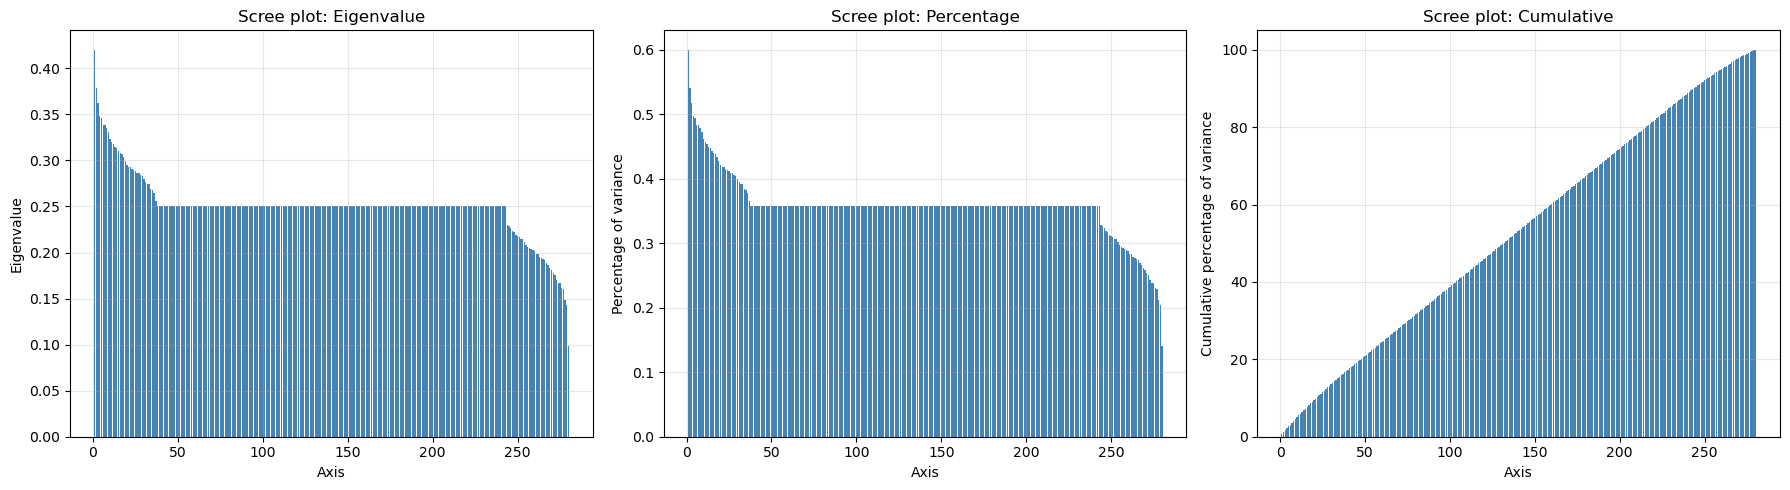

In [28]:
fig, axes = plt.subplots(1,3, figsize=(18, 5))
#scree plot
acm.plot_eigenvalues(ax=axes[0])
acm.plot_eigenvalues(ax=axes[1], type="percentage")
acm.plot_eigenvalues(ax=axes[2], type="cumulative")
plt.tight_layout()
plt.show()

## Informations sur les individus

In [29]:
#infos
info_lig = acm.row_topandas()
info_lig[:2]
# info_lig.columns

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_coord_dim38,row_coord_dim39,row_coord_dim40,row_coord_dim41,row_coord_dim42,row_coord_dim43,row_coord_dim44,row_coord_dim45,row_coord_dim46,row_coord_dim47,row_coord_dim48,row_coord_dim49,row_coord_dim50,row_coord_dim51,row_coord_dim52,row_coord_dim53,row_coord_dim54,row_coord_dim55,row_coord_dim56,row_coord_dim57,row_coord_dim58,row_coord_dim59,row_coord_dim60,row_coord_dim61,row_coord_dim62,row_coord_dim63,row_coord_dim64,row_coord_dim65,row_coord_dim66,row_coord_dim67,row_coord_dim68,row_coord_dim69,row_coord_dim70,row_coord_dim71,row_coord_dim72,row_coord_dim73,row_coord_dim74,row_coord_dim75,row_coord_dim76,row_coord_dim77,row_coord_dim78,row_coord_dim79,row_coord_dim80,row_coord_dim81,row_coord_dim82,row_coord_dim83,row_coord_dim84,row_coord_dim85,row_coord_dim86,row_coord_dim87,row_coord_dim88,row_coord_dim89,row_coord_dim90,row_coord_dim91,row_coord_dim92,row_coord_dim93,row_coord_dim94,row_coord_dim95,row_coord_dim96,row_coord_dim97,row_coord_dim98,row_coord_dim99,row_coord_dim100,row_coord_dim101,row_coord_dim102,row_coord_dim103,row_coord_dim104,row_coord_dim105,row_coord_dim106,row_coord_dim107,row_coord_dim108,row_coord_dim109,row_coord_dim110,row_coord_dim111,row_coord_dim112,row_coord_dim113,row_coord_dim114,row_coord_dim115,row_coord_dim116,row_coord_dim117,row_coord_dim118,row_coord_dim119,row_coord_dim120,row_coord_dim121,row_coord_dim122,row_coord_dim123,row_coord_dim124,row_coord_dim125,row_coord_dim126,row_coord_dim127,row_coord_dim128,row_coord_dim129,row_coord_dim130,row_coord_dim131,row_coord_dim132,row_coord_dim133,row_coord_dim134,row_coord_dim135,row_coord_dim136,row_coord_dim137,row_coord_dim138,row_coord_dim139,row_coord_dim140,row_coord_dim141,row_coord_dim142,row_coord_dim143,row_coord_dim144,row_coord_dim145,row_coord_dim146,row_coord_dim147,row_coord_dim148,row_coord_dim149,row_coord_dim150,row_coord_dim151,row_coord_dim152,row_coord_dim153,row_coord_dim154,row_coord_dim155,row_coord_dim156,row_coord_dim157,row_coord_dim158,row_coord_dim159,row_coord_dim160,row_coord_dim161,row_coord_dim162,row_coord_dim163,row_coord_dim164,row_coord_dim165,row_coord_dim166,row_coord_dim167,row_coord_dim168,row_coord_dim169,row_coord_dim170,row_coord_dim171,row_coord_dim172,row_coord_dim173,row_coord_dim174,row_coord_dim175,row_coord_dim176,row_coord_dim177,row_coord_dim178,row_coord_dim179,row_coord_dim180,row_coord_dim181,row_coord_dim182,row_coord_dim183,row_coord_dim184,row_coord_dim185,row_coord_dim186,row_coord_dim187,row_coord_dim188,row_coord_dim189,row_coord_dim190,row_coord_dim191,row_coord_dim192,row_coord_dim193,row_coord_dim194,row_coord_dim195,row_coord_dim196,row_coord_dim197,row_coord_dim198,row_coord_dim199,row_coord_dim200,row_coord_dim201,row_coord_dim202,row_coord_dim203,row_coord_dim204,row_coord_dim205,row_coord_dim206,row_coord_dim207,row_coord_dim208,row_coord_dim209,row_coord_dim210,row_coord_dim211,row_coord_dim212,row_coord_dim213,row_coord_dim214,row_coord_dim215,row_coord_dim216,row_coord_dim217,row_coord_dim218,row_coord_dim219,row_coord_dim220,row_coord_dim221,row_coord_dim222,row_coord_dim223,row_coord_dim224,row_coord_dim225,row_coord_dim226,row_coord_dim227,row_coord_dim228,row_coord_dim229,row_coord_dim230,row_coord_dim231,row_coord_dim232,row_coord_dim233,row_coord_dim234,row_coord_dim235,row_coord_dim236,row_coord_dim237,row_coord_dim238,row_coord_dim239,row_coord_dim240,row_coord_dim241,row_coord_

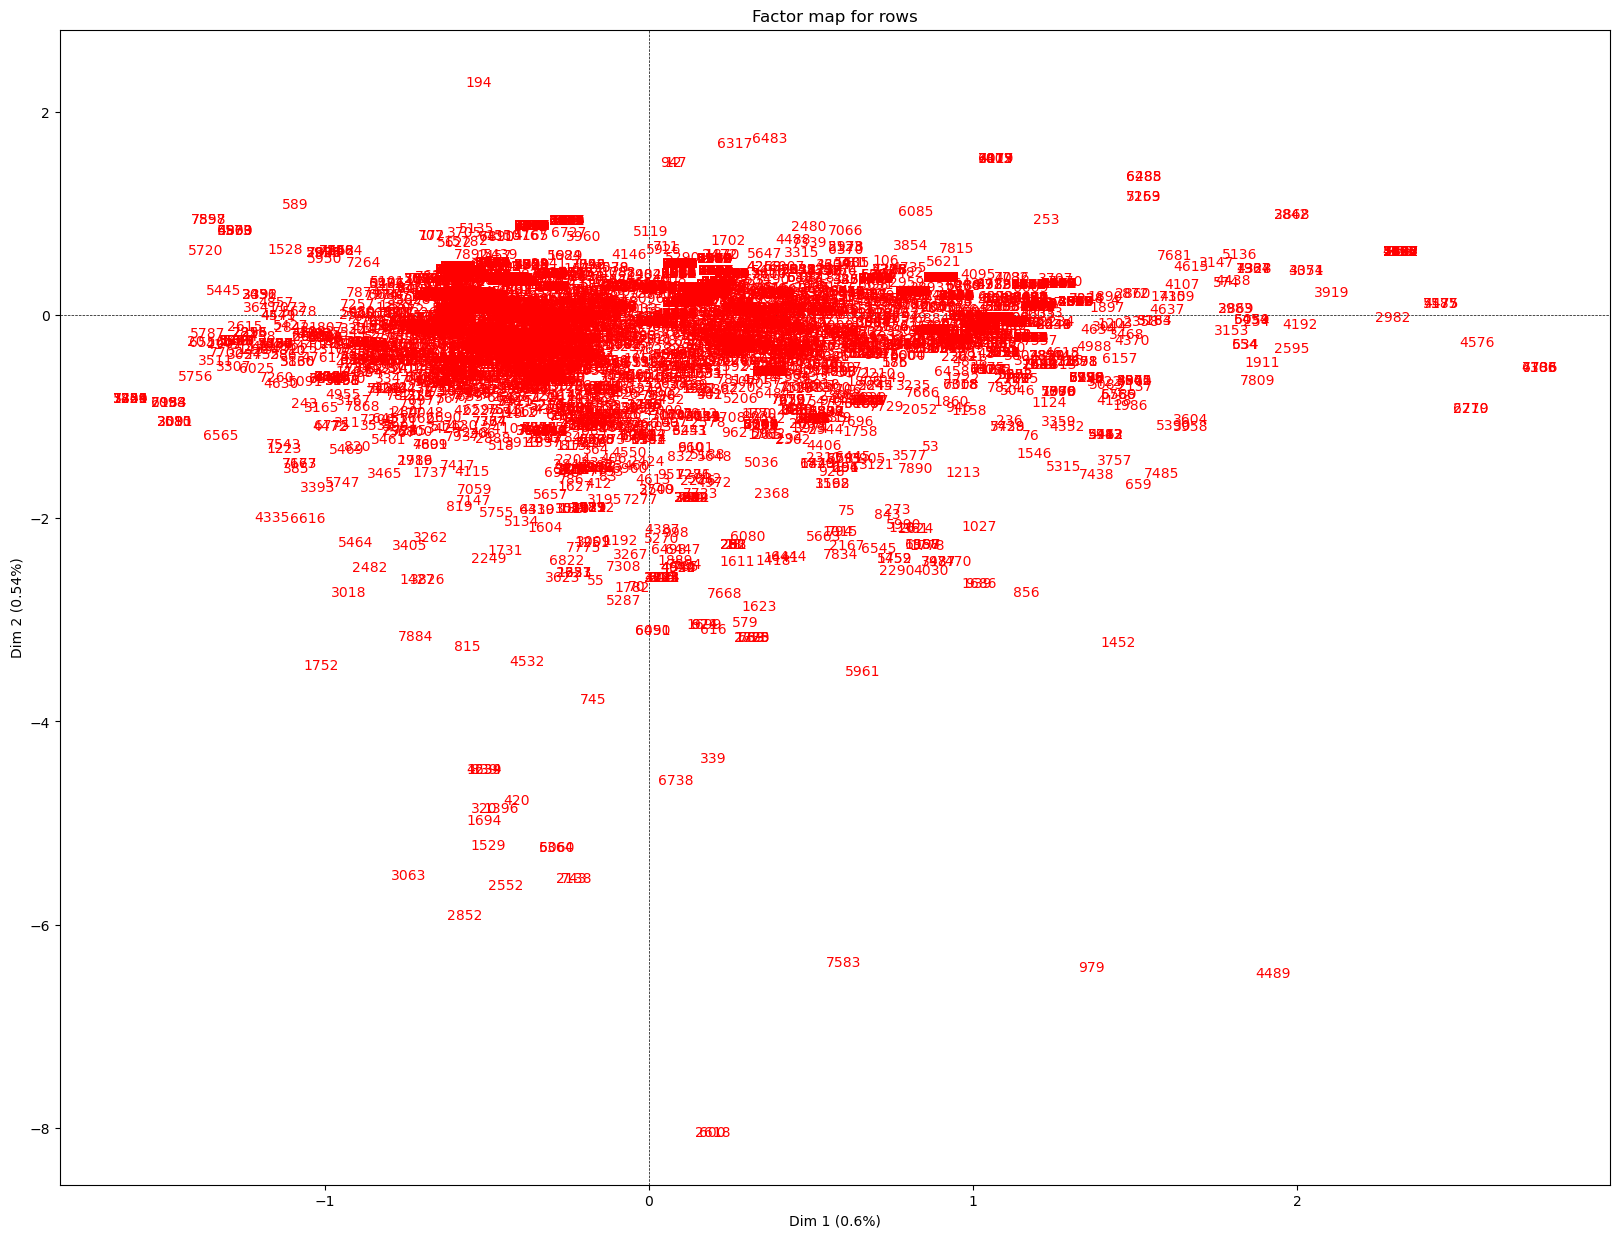

In [32]:
#nuage de points - premier plan factoriel
#points "anonymes" ici, peu intéressant affichage des index
#mais possible - cf. https://github.com/OlivierGarciaDev/fanalysis/blob/master/doc/mca_tutorial.ipynb
acm.mapping_row(num_x_axis=1,num_y_axis=2, figsize=(20,15))

## Informations sur les points-modalités

In [33]:
#coordonnées et infos
info_col = acm.col_topandas()
info_col.head(2)
# info_col.columns

,col_coord_dim1,col_coord_dim2,col_coord_dim3,col_coord_dim4,col_coord_dim5,col_coord_dim6,col_coord_dim7,col_coord_dim8,col_coord_dim9,col_coord_dim10,col_coord_dim11,col_coord_dim12,col_coord_dim13,col_coord_dim14,col_coord_dim15,col_coord_dim16,col_coord_dim17,col_coord_dim18,col_coord_dim19,col_coord_dim20,col_coord_dim21,col_coord_dim22,col_coord_dim23,col_coord_dim24,col_coord_dim25,col_coord_dim26,col_coord_dim27,col_coord_dim28,col_coord_dim29,col_coord_dim30,col_coord_dim31,col_coord_dim32,col_coord_dim33,col_coord_dim34,col_coord_dim35,col_coord_dim36,col_coord_dim37,col_coord_dim38,col_coord_dim39,col_coord_dim40,col_coord_dim41,col_coord_dim42,col_coord_dim43,col_coord_dim44,col_coord_dim45,col_coord_dim46,col_coord_dim47,col_coord_dim48,col_coord_dim49,col_coord_dim50,col_coord_dim51,col_coord_dim52,col_coord_dim53,col_coord_dim54,col_coord_dim55,col_coord_dim56,col_coord_dim57,col_coord_dim58,col_coord_dim59,col_coord_dim60,col_coord_dim61,col_coord_dim62,col_coord_dim63,col_coord_dim64,col_coord_dim65,col_coord_dim66,col_coord_dim67,col_coord_dim68,col_coord_dim69,col_coord_dim70,col_coord_dim71,col_coord_dim72,col_coord_dim73,col_coord_dim74,col_coord_dim75,col_coord_dim76,col_coord_dim77,col_coord_dim78,col_coord_dim79,col_coord_dim80,col_coord_dim81,col_coord_dim82,col_coord_dim83,col_coord_dim84,col_coord_dim85,col_coord_dim86,col_coord_dim87,col_coord_dim88,col_coord_dim89,col_coord_dim90,col_coord_dim91,col_coord_dim92,col_coord_dim93,col_coord_dim94,col_coord_dim95,col_coord_dim96,col_coord_dim97,col_coord_dim98,col_coord_dim99,col_coord_dim100,col_coord_dim101,col_coord_dim102,col_coord_dim103,col_coord_dim104,col_coord_dim105,col_coord_dim106,col_coord_dim107,col_coord_dim108,col_coord_dim109,col_coord_dim110,col_coord_dim111,col_coord_dim112,col_coord_dim113,col_coord_dim114,col_coord_dim115,col_coord_dim116,col_coord_dim117,col_coord_dim118,col_coord_dim119,col_coord_dim120,col_coord_dim121,col_coord_dim122,col_coord_dim123,col_coord_dim124,col_coord_dim125,col_coord_dim126,col_coord_dim127,col_coord_dim128,col_coord_dim129,col_coord_dim130,col_coord_dim131,col_coord_dim132,col_coord_dim133,col_coord_dim134,col_coord_dim135,col_coord_dim136,col_coord_dim137,col_coord_dim138,col_coord_dim139,col_coord_dim140,col_coord_dim141,col_coord_dim142,col_coord_dim143,col_coord_dim144,col_coord_dim145,col_coord_dim146,col_coord_dim147,col_coord_dim148,col_coord_dim149,col_coord_dim150,col_coord_dim151,col_coord_dim152,col_coord_dim153,col_coord_dim154,col_coord_dim155,col_coord_dim156,col_coord_dim157,col_coord_dim158,col_coord_dim159,col_coord_dim160,col_coord_dim161,col_coord_dim162,col_coord_dim163,col_coord_dim164,col_coord_dim165,col_coord_dim166,col_coord_dim167,col_coord_dim168,col_coord_dim169,col_coord_dim170,col_coord_dim171,col_coord_dim172,col_coord_dim173,col_coord_dim174,col_coord_dim175,col_coord_dim176,col_coord_dim177,col_coord_dim178,col_coord_dim179,col_coord_dim180,col_coord_dim181,col_coord_dim182,col_coord_dim183,col_coord_dim184,col_coord_dim185,col_coord_dim186,col_coord_dim187,col_coord_dim188,col_coord_dim189,col_coord_dim190,col_coord_dim191,col_coord_dim192,col_coord_dim193,col_coord_dim194,col_coord_dim195,col_coord_dim196,col_coord_dim197,col_coord_dim198,col_coord_dim199,col_coord_dim200,col_coord_dim201,col_coord_dim202,col_coord_dim203,col_coord_dim204,col_coord_dim205,col_coord_dim206,col_coord_dim207,col_coord_dim208,col_coord_dim209,col_coord_dim210,col_coord_dim211,col_coord_dim212,col_coord_dim213,col_coord_dim214,col_coord_dim215,col_coord_dim216,col_coord_dim217,col_coord_dim218,col_coord_dim219,col_coord_dim220,col_coord_dim221,col_coord_dim222,col_coord_dim223,col_coord_dim224,col_coord_dim225,col_coord_dim226,col_coord_dim227,col_coord_dim228,col_coord_dim229,col_coord_dim230,col_coord_dim231,col_coord_dim232,col_coord_dim233,col_coord_dim234,col_coord_dim235,col_coord_dim236,col_coord_dim237,col_coord_dim238,col_coord_dim239,col_coord_dim240,col_coord_dim241,col_coord_

In [36]:
#coordoonées dans le premier plan factoriel
coord_col = info_col[['col_coord_dim1', 'col_coord_dim2', 'col_coord_dim3']]
print(coord_col.col_coord_dim1)

gender_female                              0.417894
gender_male                               -0.032721
coded_country_Austria Hungary             -0.238453
coded_country_Baltic States Fin. Belar.   -0.868669
coded_country_Belgium Netherl.            -0.365185
                                             ...   
coded_employer_organization               -0.275140
coded_employer_other                      -0.533444
coded_employer_publisher                  -0.739596
coded_employer_school                     -0.371926
coded_employer_university                 -0.779253
Name: col_coord_dim1, Length: 284, dtype: float64


In [37]:
#MASS = poids relatif des modalités
#Livre, page 297
#Qui constitue aussi le profil moyen : Livre, page 290
col_mass = acm.c_/(n*p)
#print(col_mass)

In [38]:
#facteurs sont centrés - vérifions avec moyenne pondérée des modalités
#sur les 2 premiers facteurs
print(coord_col.apply(axis=0,func=lambda x: np.sum(col_mass[0]*x)))
    

col_coord_dim1    3.469447e-17
col_coord_dim2   -3.816392e-17
col_coord_dim3    2.255141e-17
dtype: float64


In [39]:
#dispersion = valeurs propres ==> oui, Livre Page 298
print(coord_col.apply(axis=0,func=lambda x: np.sum(col_mass[0]*(x**2))))

col_coord_dim1    0.420240
col_coord_dim2    0.378914
col_coord_dim3    0.362317
dtype: float64


### Qualitatives

In [40]:
dfa.head(2)

NameError: name 'dfa' is not defined

In [ ]:
#isoler les variables supplémentaires (ou illustratives)
df_suppl = dfa[dfa.columns[[4]]]# .reset_index()
print(df_suppl.columns)
df_suppl.head(2)

Index(['classe_maj'], dtype='object')


,classe_maj
id_comp,
1001_1,o4
1002_1,o4


In [ ]:
info_lig.head(2)

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,...,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16
id_comp,,,,,,,,,,,,,,,,,,,,,
1001_1,-0.383784,-0.525343,0.385498,0.005706,0.035666,-0.270990,0.309458,-0.058702,-0.083403,-0.536668,...,0.078723,0.002833,0.005718,0.23676,0.001985,0.037207,0.082235,0.010220,0.003972,0.008791
1002_1,-0.527914,-0.563528,0.071976,-0.017118,-0.042514,-0.001251,0.115943,0.001341,-0.030859,-0.090432,...,0.012542,0.000002,0.000888,0.00763,0.124957,0.004276,0.249121,0.017184,0.003837,0.016483


In [ ]:
df_supp_lignes = df_suppl.merge(info_lig, left_index=True, right_index=True)
df_supp_lignes.head(2)

,classe_maj,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,...,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16
id_comp,,,,,,,,,,,,,,,,,,,,,
1001_1,o4,-0.383784,-0.525343,0.385498,0.005706,0.035666,-0.270990,0.309458,-0.058702,-0.083403,...,0.078723,0.002833,0.005718,0.23676,0.001985,0.037207,0.082235,0.010220,0.003972,0.008791
1002_1,o4,-0.527914,-0.563528,0.071976,-0.017118,-0.042514,-0.001251,0.115943,0.001341,-0.030859,...,0.012542,0.000002,0.000888,0.00763,0.124957,0.004276,0.249121,0.017184,0.003837,0.016483


### Plot dim1-dim2

In [ ]:
#positionnement d'individus
coord = df_supp_lignes[['classe_maj','row_coord_dim1', 'row_coord_dim2']].copy()
print(len(coord))
coord.head(2)


337


,classe_maj,row_coord_dim1,row_coord_dim2
id_comp,,,
1001_1,o4,-0.383784,-0.525343
1002_1,o4,-0.527914,-0.563528


In [ ]:

#moyennes conditionnelles - Livre, page 341
coord_fact = pd.pivot_table(data=coord,values=['row_coord_dim1', 'row_coord_dim2'],index='classe_maj',aggfunc='mean')
coord_fact


,row_coord_dim1,row_coord_dim2
classe_maj,,
non,0.238565,-0.047278
o1,0.443722,-0.055798
o2,0.211838,-0.050887
o3,-0.135077,-0.020371
o4,-0.127803,0.094101


### Explication (LLM Claude)

This division by np.sqrt(eig_[:2]) is the standardization step to obtain factor coordinates in the normalized factorial space.
Here's why it's needed:
What you have before dividing are the raw barycenter coordinates of each classe_maj category, expressed in the same space as the individuals (row coordinates). These are in the "principal normalization" scale, where variance along axis k equals the k-th eigenvalue λₖ.
After dividing by √λₖ you project those barycenters into the standardized factorial space, where each axis has unit variance. This is equivalent to expressing the coordinates in terms of standard deviations, making axes comparable regardless of how much variance they carry.
In MCA this is the correct way to position illustrative categorical variables on the map, because:

It respects the transition formulas of MCA — the same formula used internally to project supplementary categories
It makes the coordinates scale-invariant, so distances between category points are meaningful and comparable across axes
Without it, axis 1 coordinates would be inflated relative to axis 2 (since λ₁ > λ₂ always), distorting the visual interpretation

In short: the raw mean gives you the barycenter in individual space, but dividing by √λₖ lifts it into the proper dual space of categories, which is where illustrative variables should live on the MCA biplot.

In [ ]:

#corrigés par la racine carrée des valeurs propres
# computed barycenters on 2 dimensions (row_coord_dim1 and row_coord_dim2): [:2]
coord_fact = coord_fact/np.sqrt(acm.eig_[0][:2])
print(coord_fact)

            row_coord_dim1  row_coord_dim2
classe_maj                                
non               0.427131       -0.094597
o1                0.794446       -0.111645
o2                0.379277       -0.101819
o3               -0.241845       -0.040760
o4               -0.228820        0.188286


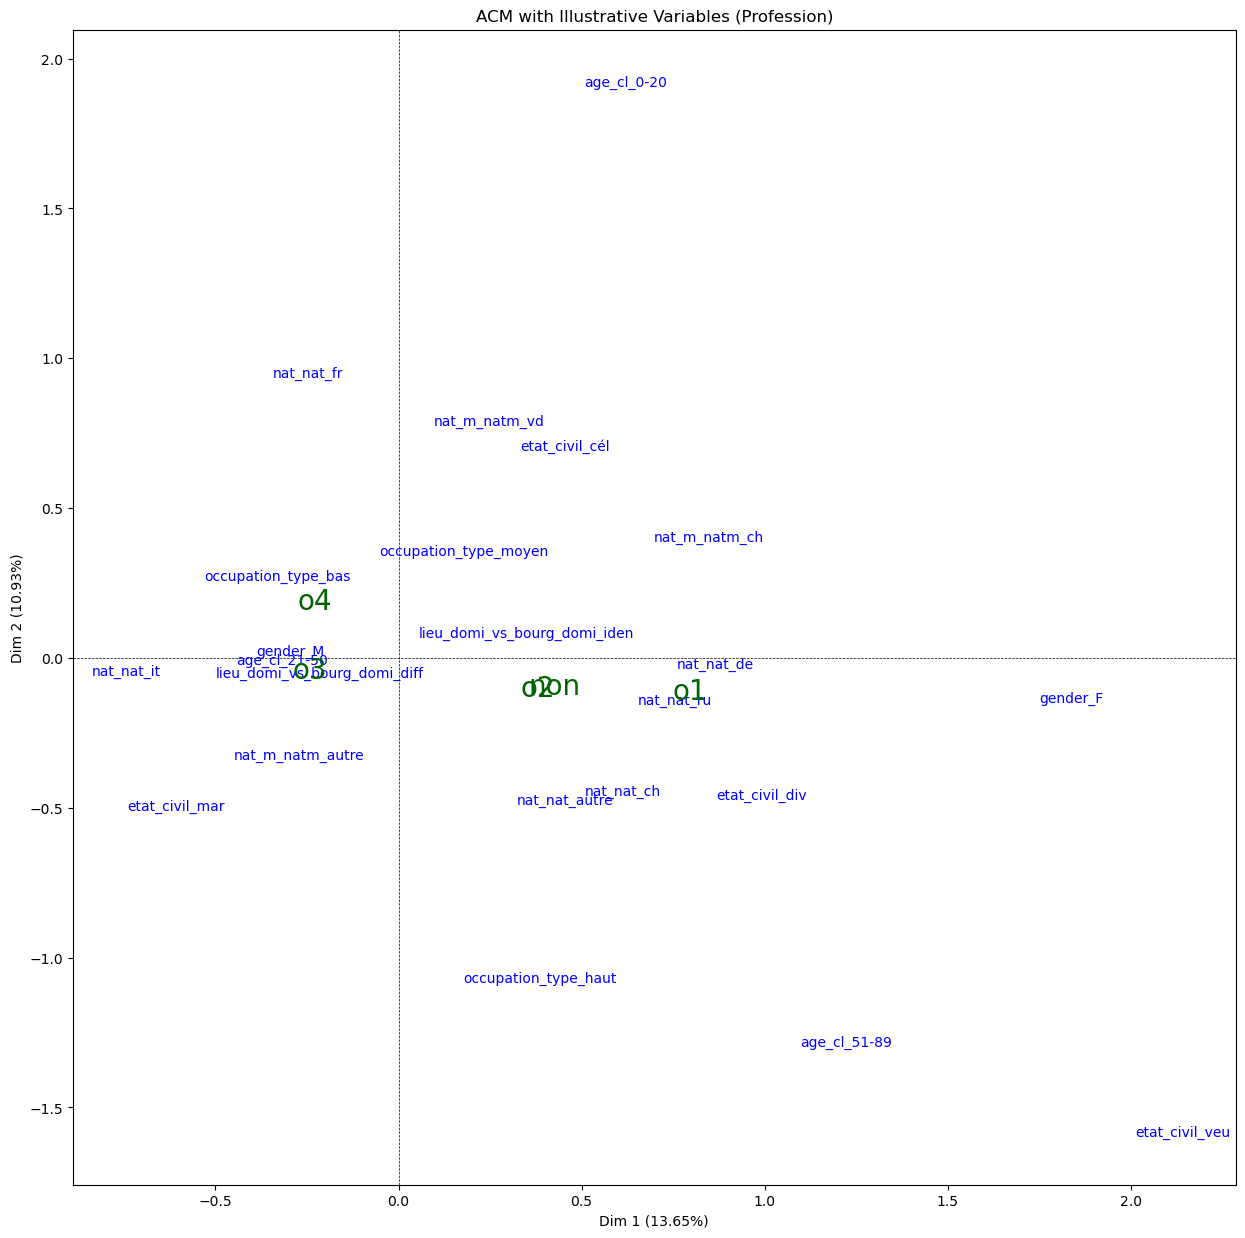

In [ ]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Plot ACM on ax
acm.mapping_col(num_x_axis=1, num_y_axis=2, ax=ax, short_labels=False)

# ✅ Add your additional layer BEFORE or AFTER

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Profession)")
plt.show()


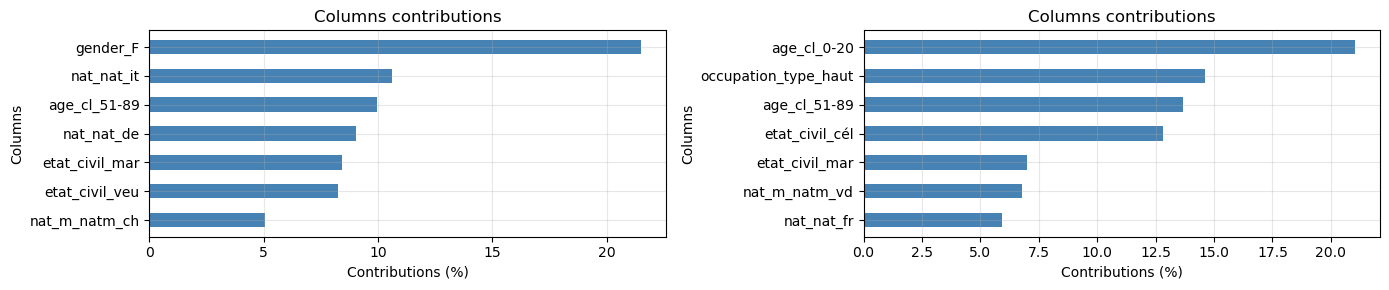

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14, 3))
acm.plot_col_contrib(num_axis=1,nb_values=7, ax = axes[0], short_labels=False)
acm.plot_col_contrib( num_axis=2,nb_values=7,ax = axes[1], short_labels=False)
plt.tight_layout()
plt.show()

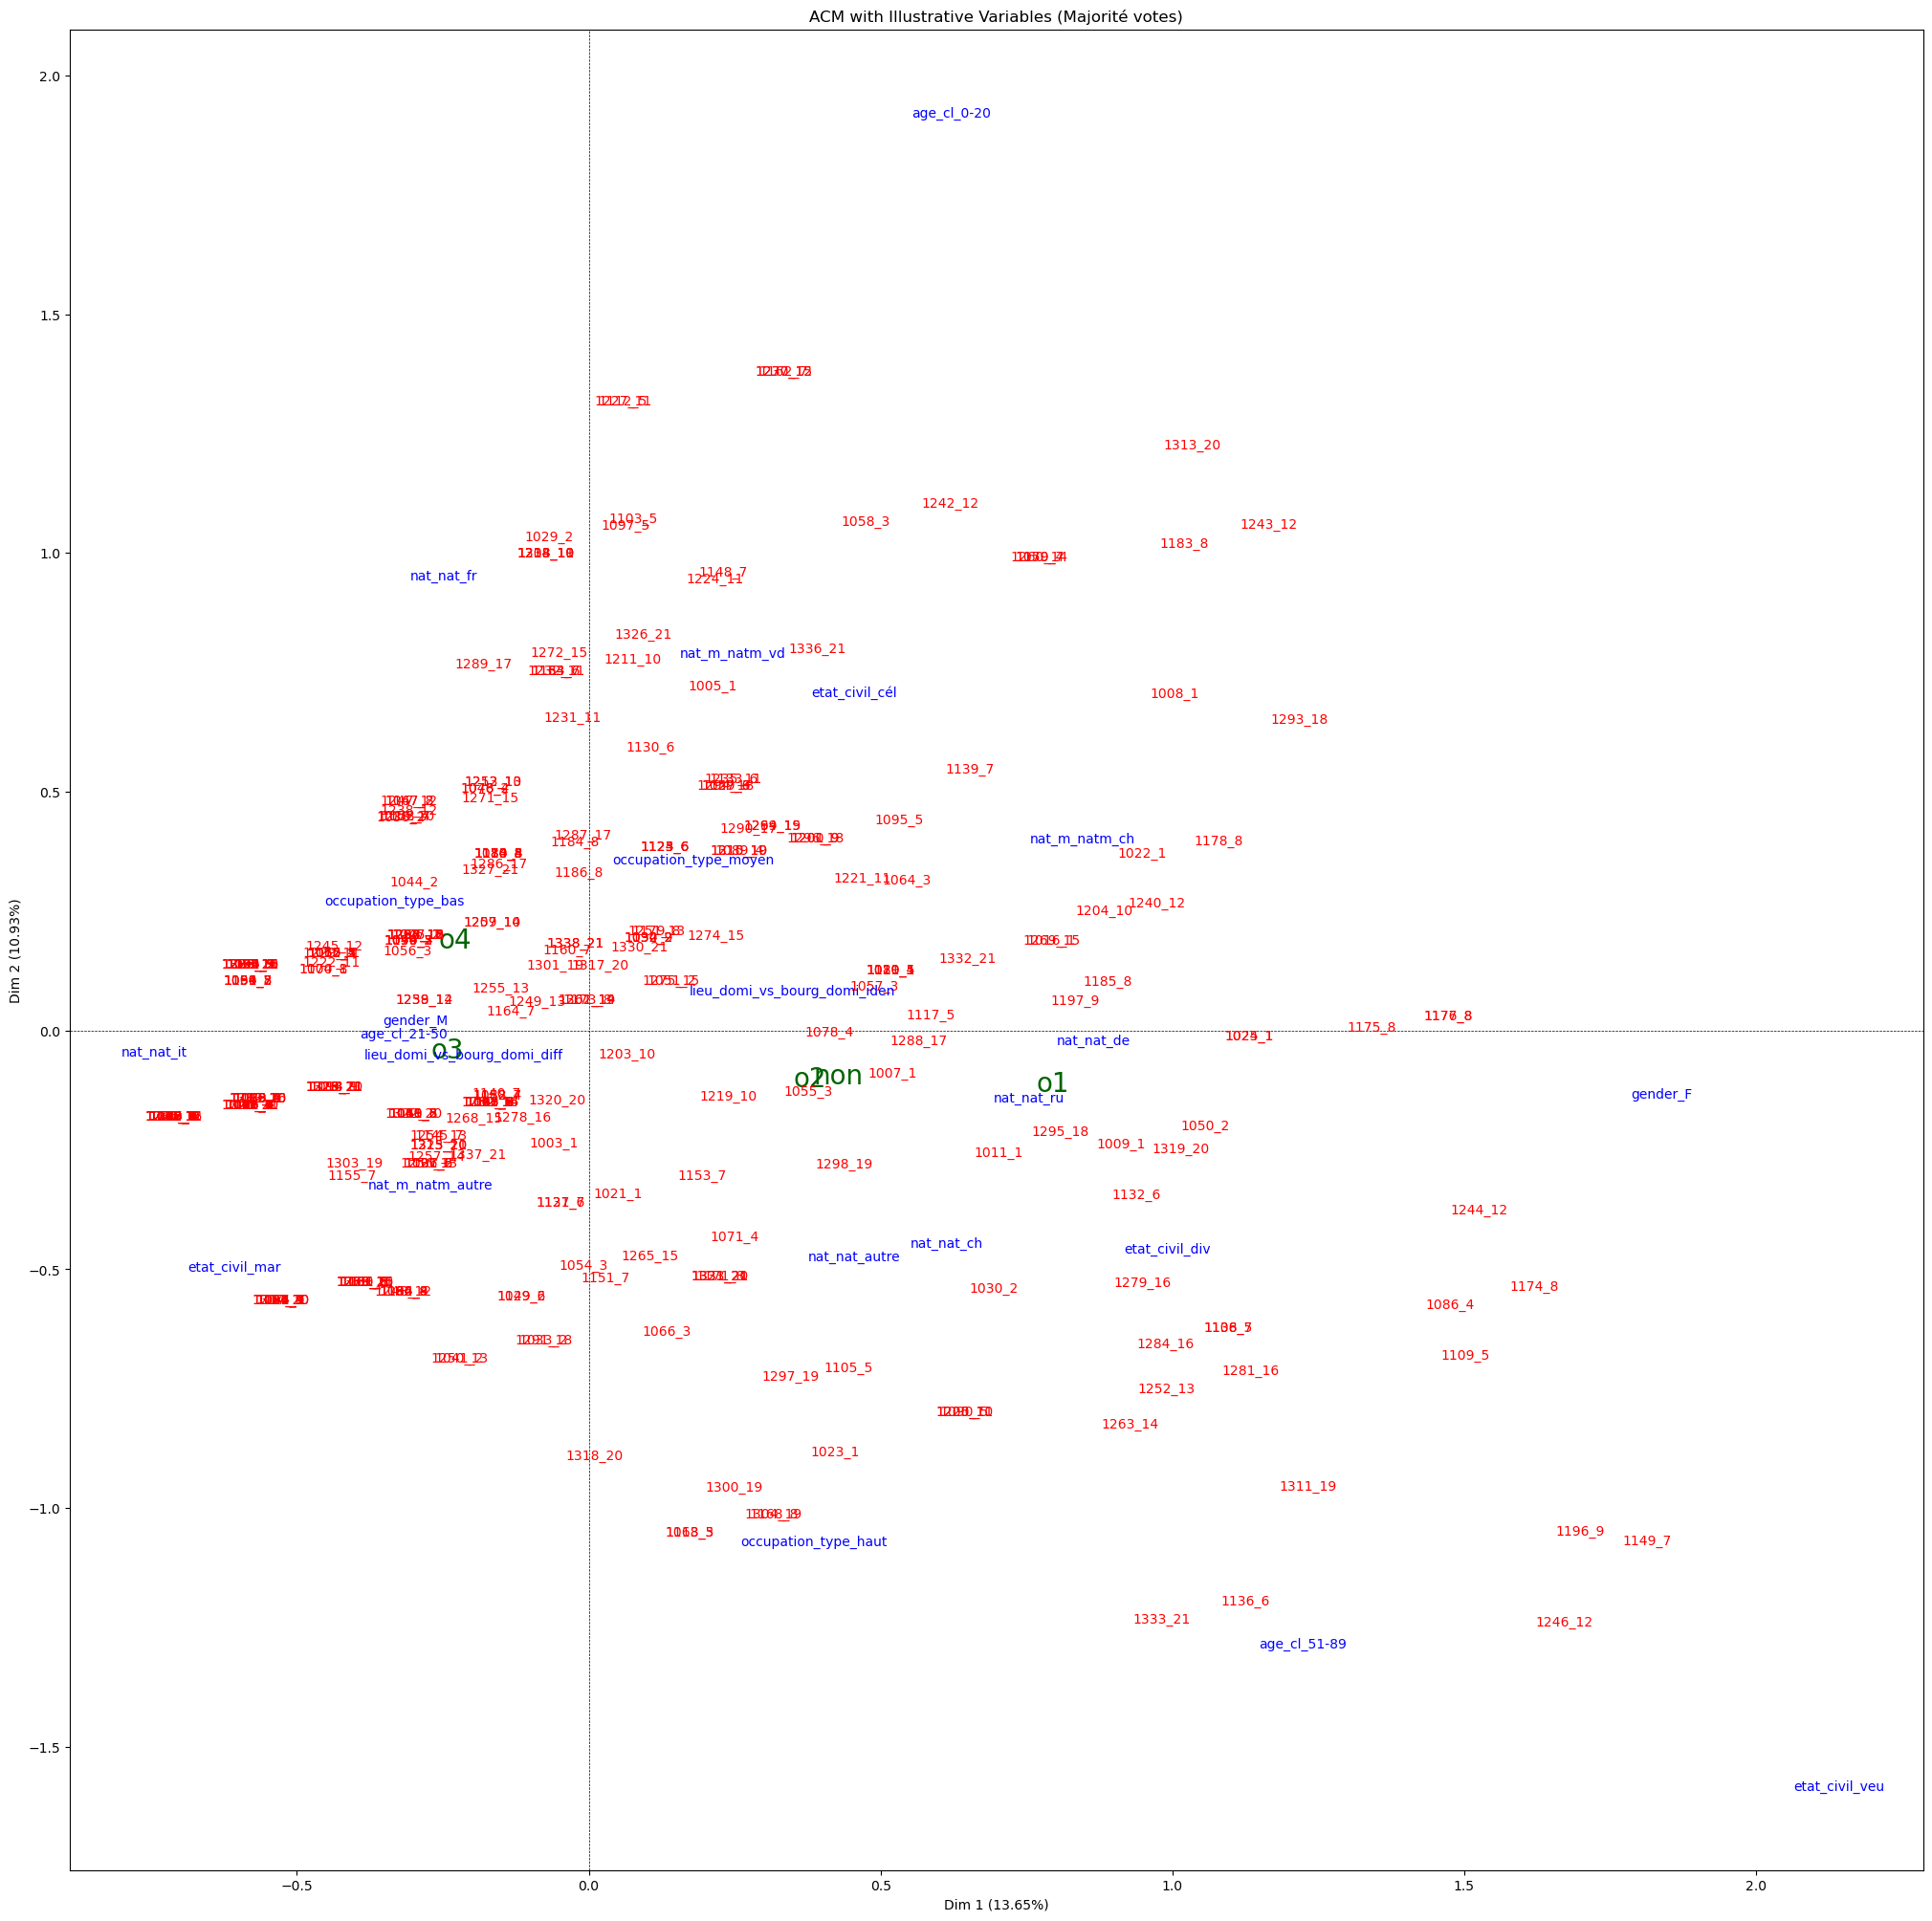

In [ ]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(25, 25))

# Plot ACM on ax
acm.mapping(num_x_axis=1, num_y_axis=2, ax=ax, short_labels=False)

# ✅ Add your additional layer BEFORE or AFTER

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Majorité votes)")
plt.show()


### Axes 3 et 4

In [ ]:
#positionnement d'individus
coord = df_supp_lignes[['classe_maj','row_coord_dim3', 'row_coord_dim4']].copy()
#moyennes conditionnelles - Livre, page 341
coord_fact = pd.pivot_table(data=coord,values=['row_coord_dim3', 'row_coord_dim4'],index='classe_maj',aggfunc='mean')
# computed barycenters on 2 dimensions 3 and 4 here
coord_fact = coord_fact/np.sqrt(acm.eig_[0][2:4])
print(coord_fact)

            row_coord_dim3  row_coord_dim4
classe_maj                                
non              -0.405033        0.507423
o1               -0.360240        0.073846
o2               -0.408660        0.290984
o3                0.001573       -0.154287
o4                0.458411       -0.035571


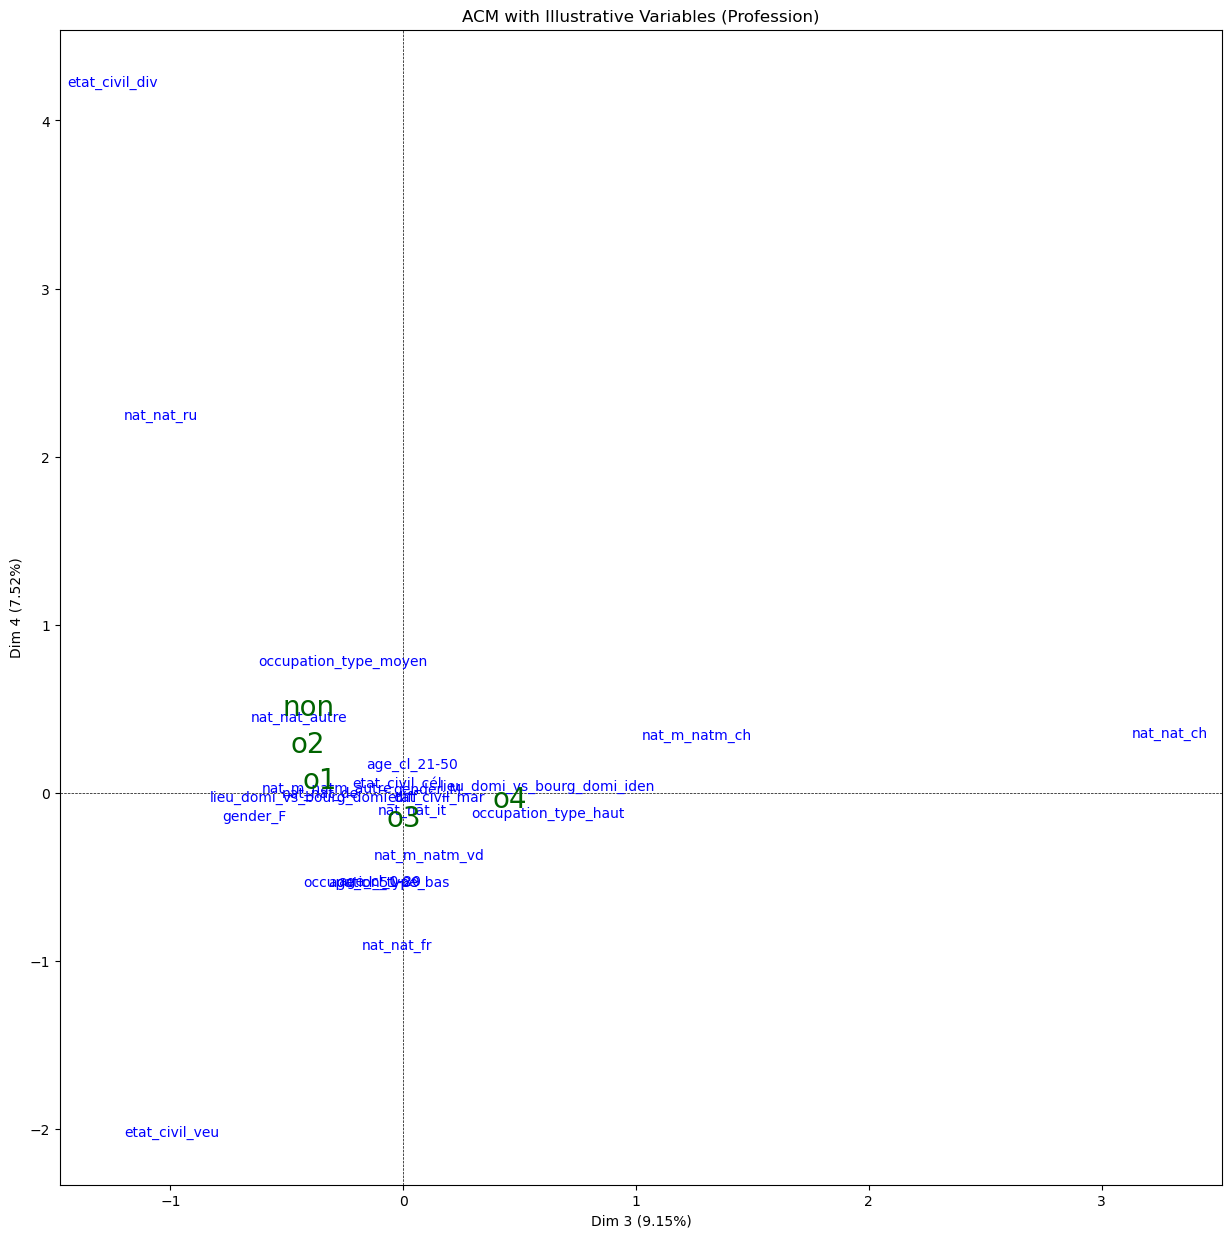

In [ ]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Plot ACM on ax
acm.mapping_col(num_x_axis=3, num_y_axis=4, ax=ax, short_labels=False)

# ✅ Add your additional layer BEFORE or AFTER

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Profession)")
plt.show()


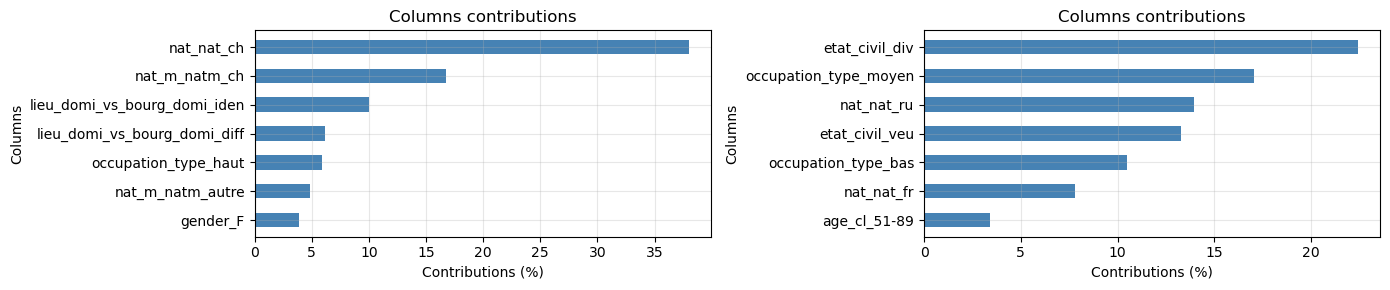

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14, 3))
acm.plot_col_contrib(num_axis=3,nb_values=7, ax = axes[0], short_labels=False)
acm.plot_col_contrib( num_axis=4,nb_values=7,ax = axes[1], short_labels=False)
plt.tight_layout()
plt.show()

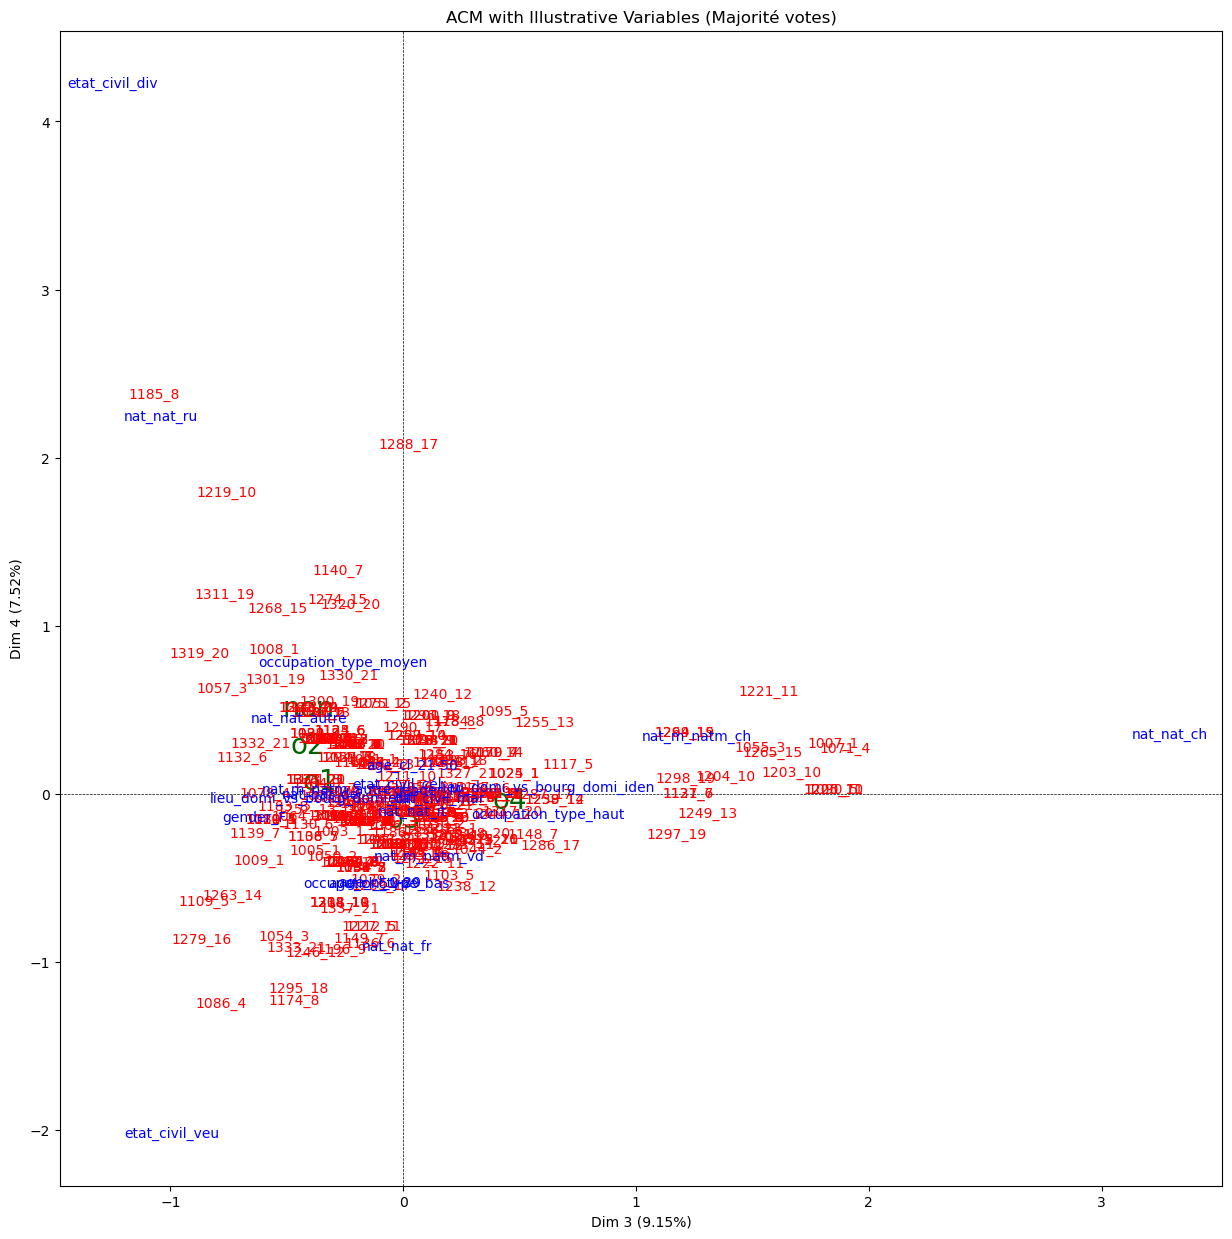

In [ ]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Plot ACM on ax
acm.mapping(num_x_axis=3, num_y_axis=4, ax=ax, short_labels=False)

# ✅ Add your additional layer BEFORE or AFTER

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Majorité votes)")
plt.show()


# Analyse de la troisième période

In [106]:
### On ne garde que la première période
## On élimine les cinquante lignes avec les métiers non renseignés
dfa = df.query("occupation_type != 'nr' and classe_3_per == 'p3'")
print(len(dfa))

581


In [113]:
#isoler les variables actives
df_actives = dfa[dfa.columns[[5,14,13,7,8,10,12]]]
print(df_actives.columns)
df_actives.head(2)

Index(['diff', 'lieu_domi_vs_bourg', 'nat_w', 'gender', 'age', 'nat_m',
       'etat_civil'],
      dtype='object')


,diff,lieu_domi_vs_bourg,nat_w,gender,age,nat_m,etat_civil
id_comp,,,,,,,
1940_61,14,domi_diff,natw_null,M,22.0,natm_vd,cél
1941_61,6,domi_iden,natw_null,M,21.0,natm_autre,cél


In [114]:
#nombre d'obs.
n = df_actives.shape[0]
print(n)

#nombre de var.
p = df_actives.shape[1]
print(p)

581
7


In [115]:
#nombre total de modalités

M = np.sum(df_actives.apply(axis=0,func=lambda x:x.value_counts().shape[0]))
print(M)
#nombre max de facteurs (Livre, page 293)
print(M-p)
#inertie totale - Livre, page 299
print(M/p-1)

161
154
22.0


## ACM avec fanalysis

In [116]:
#instanciation de l'objet à analyser
acm = MCA(row_labels=df_actives.index,var_labels=df_actives.columns)

#exécution
acm.fit(df_actives.values)

#valeurs propres
print(acm.eig_)

ValueError: Unknown label type: (array([14, 6, 6, 3, -3, 21, -1, 21, 0, 0, 3, 16, -2, -6, -3, 31, -2, 10,
       0, 42, 22, 25, 24, 30, 33, 38, 31, 16, 30, 30, 24, 20, 16, 27, 26,
       22, 46, 46, 45, 27, 33, 36, 30, 29, 30, 32, 31, 27, 25, 25, 24, 26,
       26, 33, 31, 27, 25, 29, 25, 29, 30, 32, 33, 25, 28, 28, 29, 32, 31,
       29, 33, 34, 34, 35, 29, 29, 33, 35, 35, 33, 29, 30, 29, 35, 35, 32,
       68, 69, 61, 22, 25, 20, 6, 12, 25, 27, 23, 38, 28, 30, 20, 22, 29,
       25, 9, 12, -3, 21, 17, 21, 29, 23, 15, -1, 21, 13, 13, 19, 19, 14,
       20, 38, 27, 26, 16, 28, 30, 34, 27, 19, 39, 31, 20, 44, 5, 6, 23,
       20, 20, 21, 14, 21, -3, 31, 13, 26, 22, 24, 34, 35, 26, 55, 62, 4,
       16, 31, 9, 13, 12, 17, -6, 34, 3, 22, 5, 11, 13, 4, 22, -3, 33, 11,
       30, 41, 20, 27, 30, 10, 28, 33, 37, 18, 33, -6, 34, 5, 26, 17, 1,
       26, 25, 32, -3, 33, 12, 13, 25, 55, 55, 56, 15, 22, 4, 14, 19, 8,
       7, 8, 21, 19, 19, 12, 23, 24, 24, 12, 14, 10, 0, 14, 16, 14, 14,
       

In [111]:
# inertie (variation) totale = somme des val.p
print(np.sum(acm.eig_[0]))

AttributeError: 'MCA' object has no attribute 'eig_'

AttributeError: 'MCA' object has no attribute 'eig_'

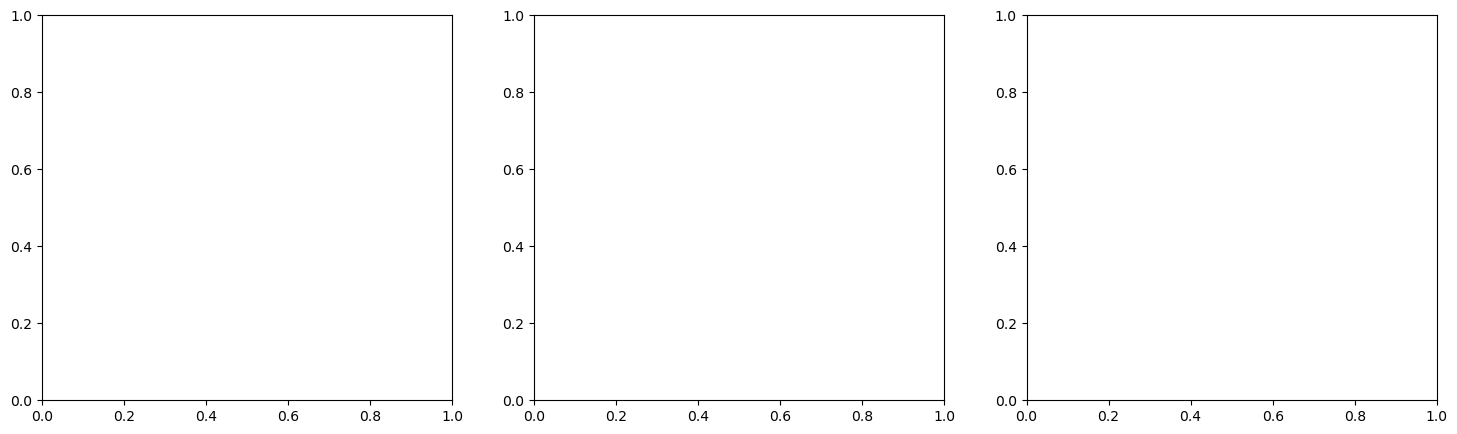

In [112]:
fig, axes = plt.subplots(1,3, figsize=(18, 5))
#scree plot
acm.plot_eigenvalues(ax=axes[0])
acm.plot_eigenvalues(ax=axes[1], type="percentage")
acm.plot_eigenvalues(ax=axes[2], type="cumulative")
plt.tight_layout()
plt.show()

## Informations sur les individus

In [ ]:
#infos
info_lig = acm.row_topandas()
info_lig[:2]
# info_lig.columns

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,...,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16
id_comp,,,,,,,,,,,,,,,,,,,,,
1001_1,-0.383784,-0.525343,0.385498,0.005706,0.035666,-0.270990,0.309458,-0.058702,-0.083403,-0.536668,...,0.078723,0.002833,0.005718,0.23676,0.001985,0.037207,0.082235,0.010220,0.003972,0.008791
1002_1,-0.527914,-0.563528,0.071976,-0.017118,-0.042514,-0.001251,0.115943,0.001341,-0.030859,-0.090432,...,0.012542,0.000002,0.000888,0.00763,0.124957,0.004276,0.249121,0.017184,0.003837,0.016483


In [ ]:
#nuage de points - premier plan factoriel
#points "anonymes" ici, peu intéressant affichage des index
#mais possible - cf. https://github.com/OlivierGarciaDev/fanalysis/blob/master/doc/mca_tutorial.ipynb
#acm.mapping_row(num_x_axis=1,num_y_axis=2)

## Informations sur les points-modalités

In [ ]:
#coordonnées et infos
info_col = acm.col_topandas()
info_col.head(2)
# info_col.columns

,col_coord_dim1,col_coord_dim2,col_coord_dim3,col_coord_dim4,col_coord_dim5,col_coord_dim6,col_coord_dim7,col_coord_dim8,col_coord_dim9,col_coord_dim10,...,col_cos2_dim7,col_cos2_dim8,col_cos2_dim9,col_cos2_dim10,col_cos2_dim11,col_cos2_dim12,col_cos2_dim13,col_cos2_dim14,col_cos2_dim15,col_cos2_dim16
gender_F,1.838406,-0.133131,-0.637579,-0.137261,0.464420,-0.023225,0.135194,-0.293252,0.092295,0.304564,...,0.00295,0.01388,0.001375,0.014972,2.344093e-09,0.061491,0.001511,0.116351,0.016275,0.11928
gender_M,-0.296725,0.021488,0.102908,0.022154,-0.074959,0.003749,-0.021821,0.047332,-0.014897,-0.049158,...,0.00295,0.01388,0.001375,0.014972,2.344093e-09,0.061491,0.001511,0.116351,0.016275,0.11928


In [ ]:
#coordoonées dans le premier plan factoriel
coord_col = info_col[['col_coord_dim1', 'col_coord_dim2', 'col_coord_dim3']]
print(coord_col.col_coord_dim1)

gender_F                        1.838406
gender_M                       -0.296725
age_cl_0-20                     0.621234
age_cl_21-50                   -0.316890
age_cl_51-89                    1.223372
occupation_type_bas            -0.332081
occupation_type_haut            0.386019
occupation_type_moyen           0.179445
nat_nat_autre                   0.454753
nat_nat_ch                      0.613719
nat_nat_de                      0.865421
nat_nat_fr                     -0.248526
nat_nat_it                     -0.744682
nat_nat_ru                      0.754099
nat_m_natm_autre               -0.270581
nat_m_natm_ch                   0.846491
nat_m_natm_vd                   0.246747
etat_civil_cél                  0.454720
etat_civil_div                  0.991086
etat_civil_mar                 -0.606626
etat_civil_veu                  2.141481
lieu_domi_vs_bourg_domi_diff   -0.214506
lieu_domi_vs_bourg_domi_iden    0.348998
Name: col_coord_dim1, dtype: float64


In [ ]:
#MASS = poids relatif des modalités
#Livre, page 297
#Qui constitue aussi le profil moyen : Livre, page 290
col_mass = acm.c_/(n*p)
#print(col_mass)

In [ ]:
#facteurs sont centrés - vérifions avec moyenne pondérée des modalités
#sur les 2 premiers facteurs
#print(coord_col.apply(axis=0,func=lambda x: np.sum(col_mass[0]*x)))
    

In [ ]:
#dispersion = valeurs propres ==> oui, Livre Page 298
#print(coord_col.apply(axis=0,func=lambda x: np.sum(col_mass[0]*(x**2))))

### Qualitatives

In [ ]:
dfa.head(2)

,annee,classe_3_per,classe_4_per,diff,classe_maj,gender,age,nat,nat_m,birth_place,etat_civil,nat_w,lieu_domi_vs_bourg,occupation_type,age_cl
id_comp,,,,,,,,,,,,,,,
1001_1,1917,p1,p1,57,o4,M,37.0,nat_it,natm_autre,birth_autre,mar,natw_ch,domi_iden,haut,21-50
1002_1,1917,p1,p1,57,o4,M,36.0,nat_it,natm_autre,birth_autre,mar,natw_autre,domi_diff,haut,21-50


In [ ]:
#isoler les variables supplémentaires (ou illustratives)
df_suppl = dfa[dfa.columns[[4]]]# .reset_index()
print(df_suppl.columns)
df_suppl.head(2)

Index(['classe_maj'], dtype='object')


,classe_maj
id_comp,
1001_1,o4
1002_1,o4


In [ ]:
info_lig.head(2)

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,...,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16
id_comp,,,,,,,,,,,,,,,,,,,,,
1001_1,-0.383784,-0.525343,0.385498,0.005706,0.035666,-0.270990,0.309458,-0.058702,-0.083403,-0.536668,...,0.078723,0.002833,0.005718,0.23676,0.001985,0.037207,0.082235,0.010220,0.003972,0.008791
1002_1,-0.527914,-0.563528,0.071976,-0.017118,-0.042514,-0.001251,0.115943,0.001341,-0.030859,-0.090432,...,0.012542,0.000002,0.000888,0.00763,0.124957,0.004276,0.249121,0.017184,0.003837,0.016483


In [ ]:
df_supp_lignes = df_suppl.merge(info_lig, left_index=True, right_index=True)
df_supp_lignes.head(2)

,classe_maj,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,...,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16
id_comp,,,,,,,,,,,,,,,,,,,,,
1001_1,o4,-0.383784,-0.525343,0.385498,0.005706,0.035666,-0.270990,0.309458,-0.058702,-0.083403,...,0.078723,0.002833,0.005718,0.23676,0.001985,0.037207,0.082235,0.010220,0.003972,0.008791
1002_1,o4,-0.527914,-0.563528,0.071976,-0.017118,-0.042514,-0.001251,0.115943,0.001341,-0.030859,...,0.012542,0.000002,0.000888,0.00763,0.124957,0.004276,0.249121,0.017184,0.003837,0.016483


### Plot dim1-dim2

In [ ]:
#positionnement d'individus
coord = df_supp_lignes[['classe_maj','row_coord_dim1', 'row_coord_dim2']].copy()
print(len(coord))
coord.head(2)


337


,classe_maj,row_coord_dim1,row_coord_dim2
id_comp,,,
1001_1,o4,-0.383784,-0.525343
1002_1,o4,-0.527914,-0.563528


In [ ]:

#moyennes conditionnelles - Livre, page 341
coord_fact = pd.pivot_table(data=coord,values=['row_coord_dim1', 'row_coord_dim2'],index='classe_maj',aggfunc='mean')
coord_fact


,row_coord_dim1,row_coord_dim2
classe_maj,,
non,0.238565,-0.047278
o1,0.443722,-0.055798
o2,0.211838,-0.050887
o3,-0.135077,-0.020371
o4,-0.127803,0.094101


### Explication (LLM Claude)

This division by np.sqrt(eig_[:2]) is the standardization step to obtain factor coordinates in the normalized factorial space.
Here's why it's needed:
What you have before dividing are the raw barycenter coordinates of each classe_maj category, expressed in the same space as the individuals (row coordinates). These are in the "principal normalization" scale, where variance along axis k equals the k-th eigenvalue λₖ.
After dividing by √λₖ you project those barycenters into the standardized factorial space, where each axis has unit variance. This is equivalent to expressing the coordinates in terms of standard deviations, making axes comparable regardless of how much variance they carry.
In MCA this is the correct way to position illustrative categorical variables on the map, because:

It respects the transition formulas of MCA — the same formula used internally to project supplementary categories
It makes the coordinates scale-invariant, so distances between category points are meaningful and comparable across axes
Without it, axis 1 coordinates would be inflated relative to axis 2 (since λ₁ > λ₂ always), distorting the visual interpretation

In short: the raw mean gives you the barycenter in individual space, but dividing by √λₖ lifts it into the proper dual space of categories, which is where illustrative variables should live on the MCA biplot.

In [ ]:

#corrigés par la racine carrée des valeurs propres
# computed barycenters on 2 dimensions (row_coord_dim1 and row_coord_dim2): [:2]
coord_fact = coord_fact/np.sqrt(acm.eig_[0][:2])
print(coord_fact)

            row_coord_dim1  row_coord_dim2
classe_maj                                
non               0.427131       -0.094597
o1                0.794446       -0.111645
o2                0.379277       -0.101819
o3               -0.241845       -0.040760
o4               -0.228820        0.188286


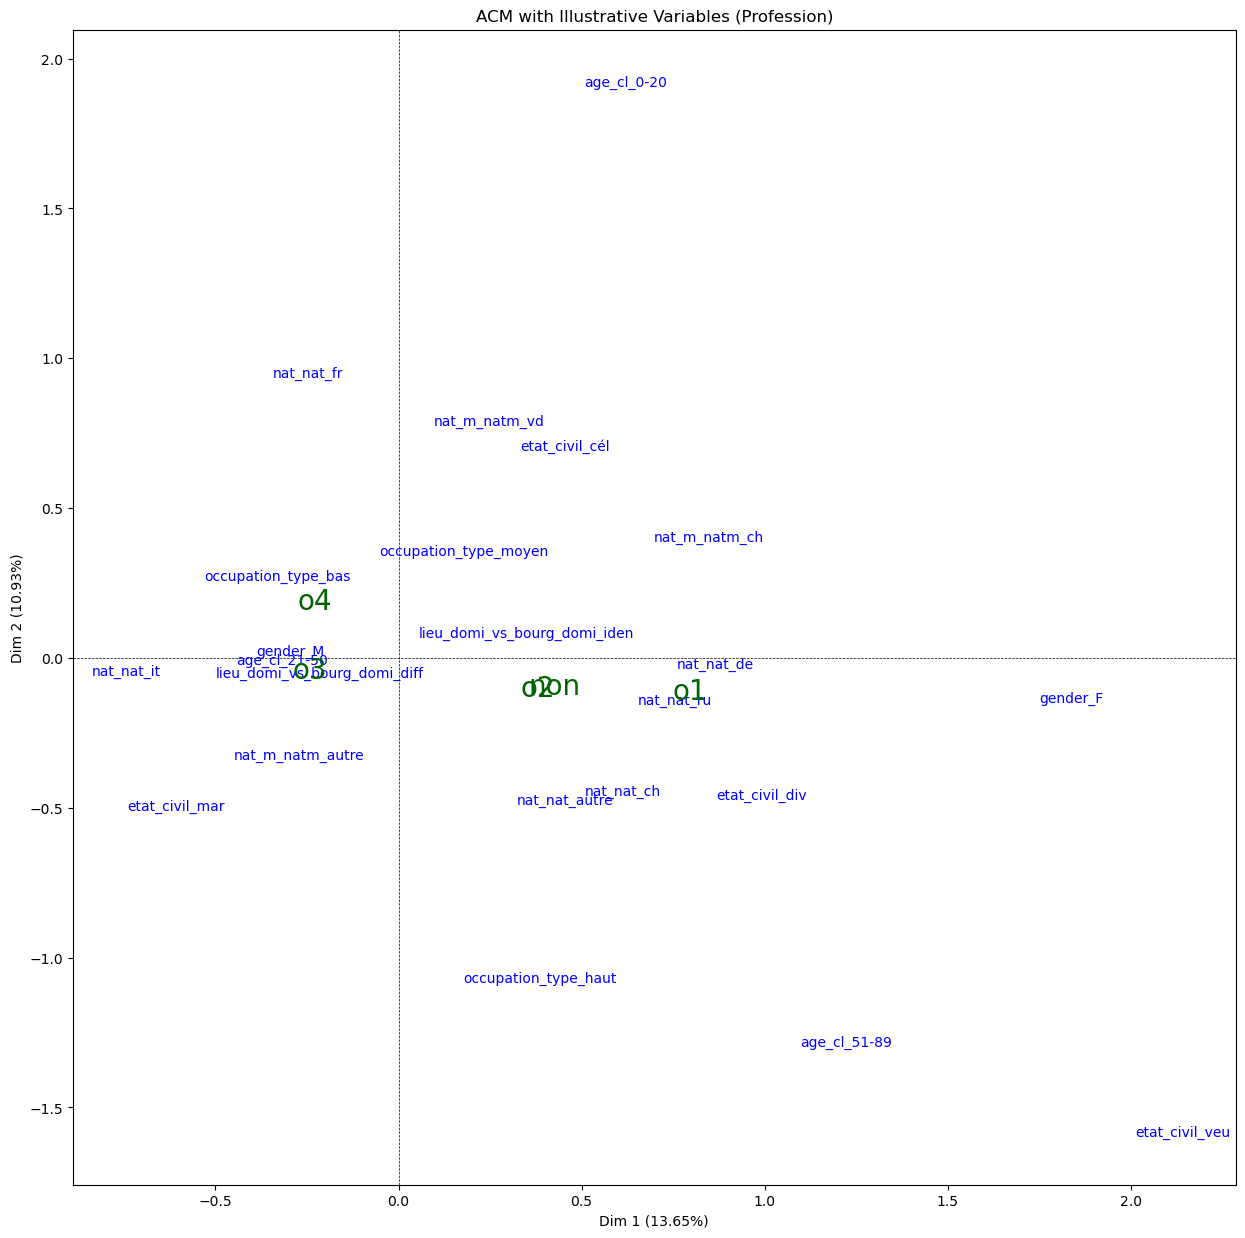

In [ ]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Plot ACM on ax
acm.mapping_col(num_x_axis=1, num_y_axis=2, ax=ax, short_labels=False)

# ✅ Add your additional layer BEFORE or AFTER

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Profession)")
plt.show()


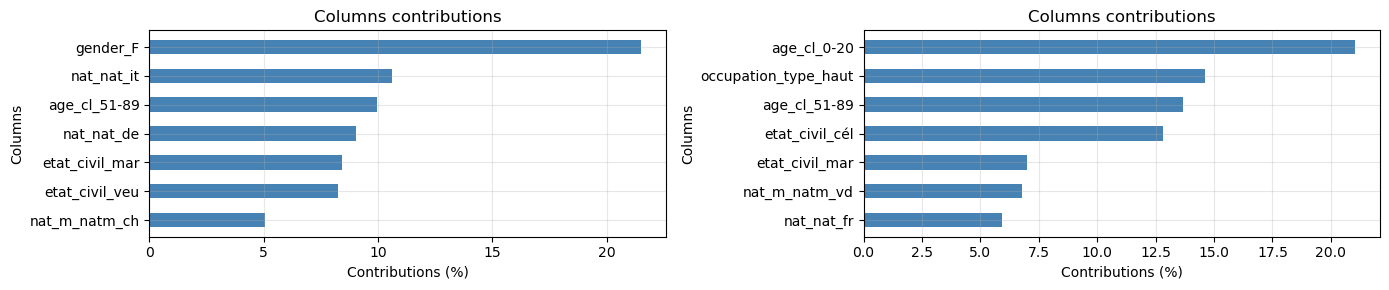

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14, 3))
acm.plot_col_contrib(num_axis=1,nb_values=7, ax = axes[0], short_labels=False)
acm.plot_col_contrib( num_axis=2,nb_values=7,ax = axes[1], short_labels=False)
plt.tight_layout()
plt.show()

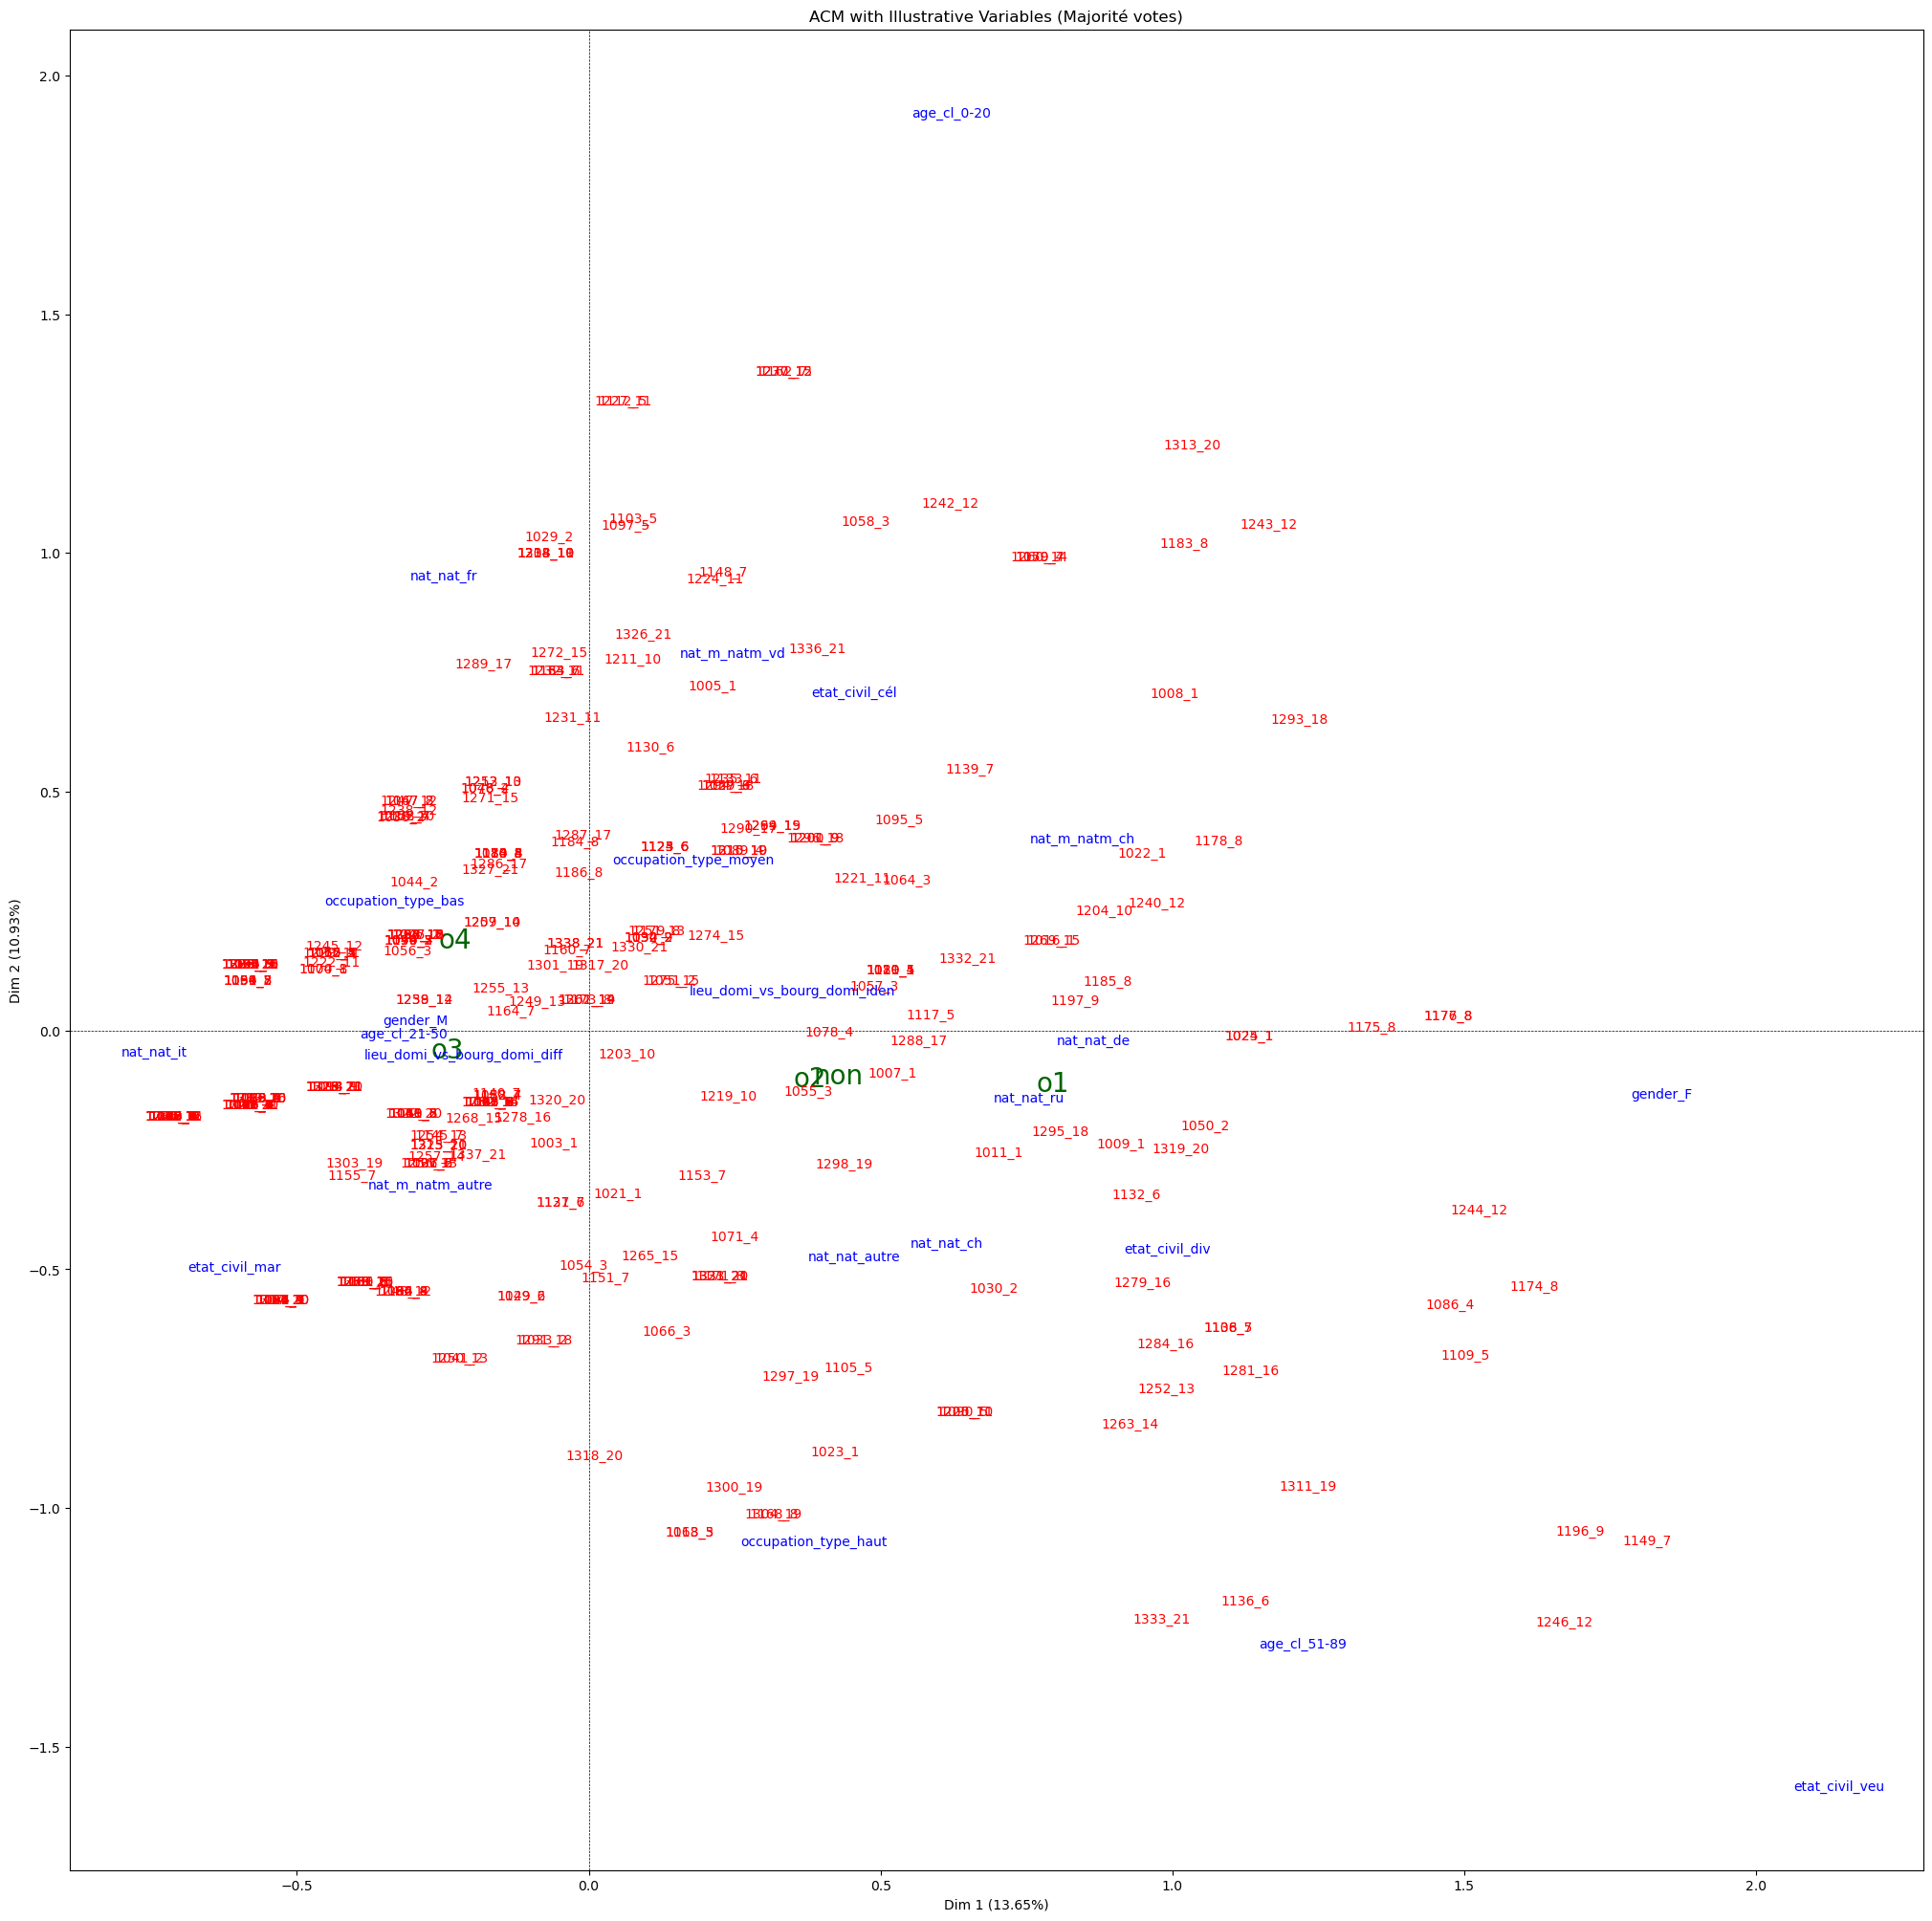

In [ ]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(25, 25))

# Plot ACM on ax
acm.mapping(num_x_axis=1, num_y_axis=2, ax=ax, short_labels=False)

# ✅ Add your additional layer BEFORE or AFTER

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Majorité votes)")
plt.show()


### Axes 3 et 4

In [ ]:
#positionnement d'individus
coord = df_supp_lignes[['classe_maj','row_coord_dim3', 'row_coord_dim4']].copy()
#moyennes conditionnelles - Livre, page 341
coord_fact = pd.pivot_table(data=coord,values=['row_coord_dim3', 'row_coord_dim4'],index='classe_maj',aggfunc='mean')
# computed barycenters on 2 dimensions 3 and 4 here
coord_fact = coord_fact/np.sqrt(acm.eig_[0][2:4])
print(coord_fact)

            row_coord_dim3  row_coord_dim4
classe_maj                                
non              -0.405033        0.507423
o1               -0.360240        0.073846
o2               -0.408660        0.290984
o3                0.001573       -0.154287
o4                0.458411       -0.035571


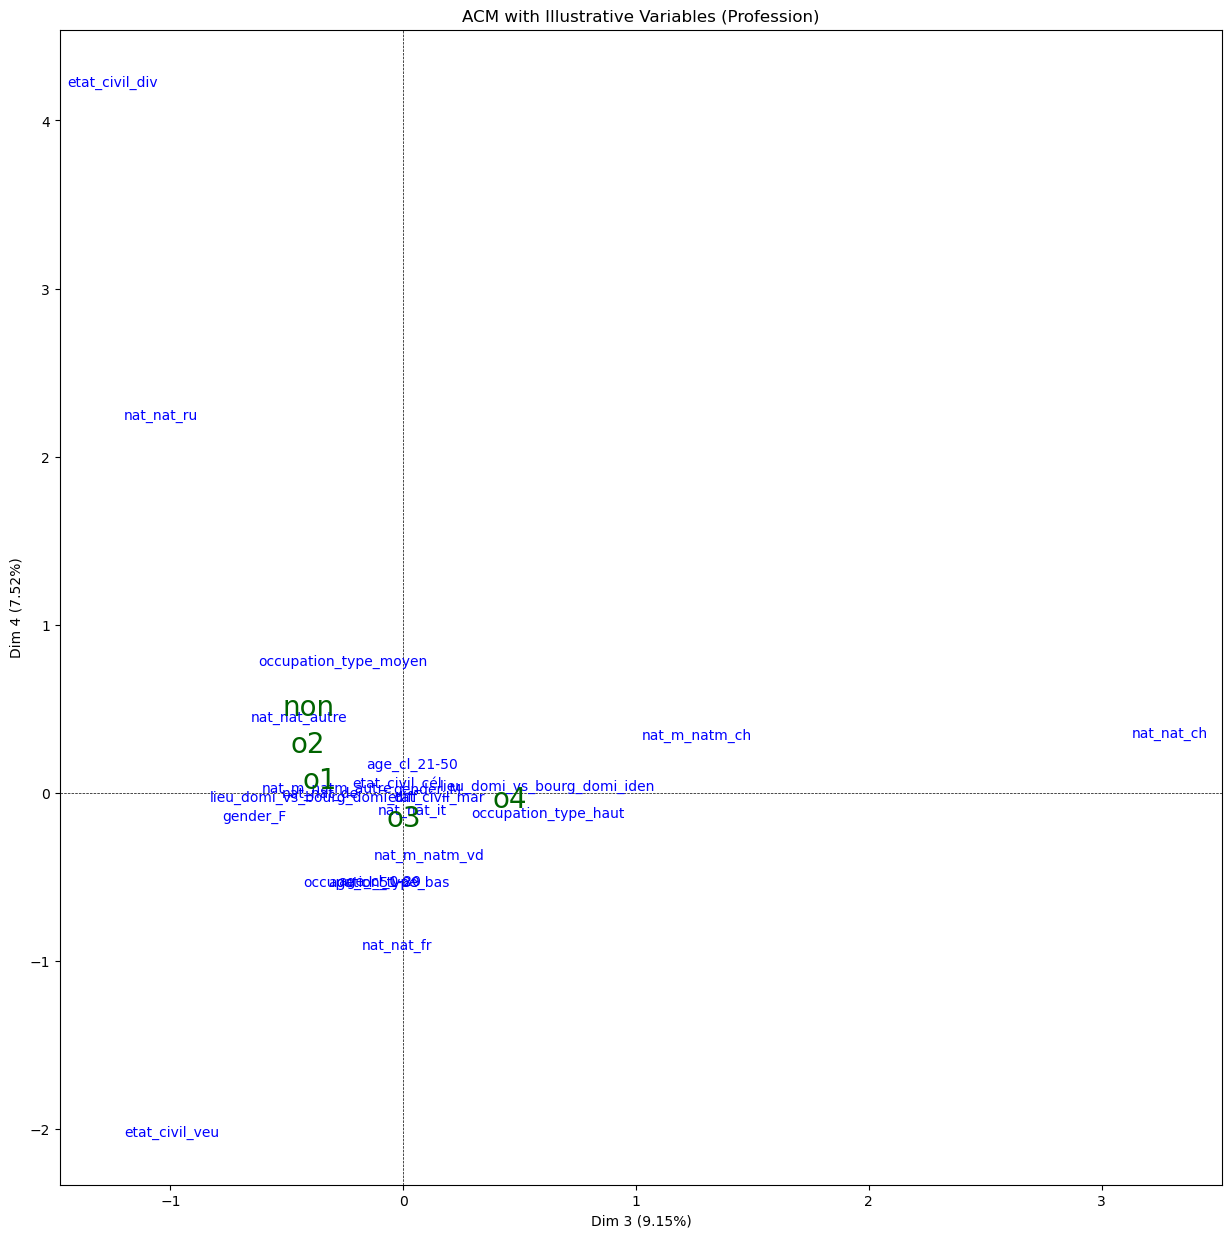

In [ ]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Plot ACM on ax
acm.mapping_col(num_x_axis=3, num_y_axis=4, ax=ax, short_labels=False)

# ✅ Add your additional layer BEFORE or AFTER

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Profession)")
plt.show()


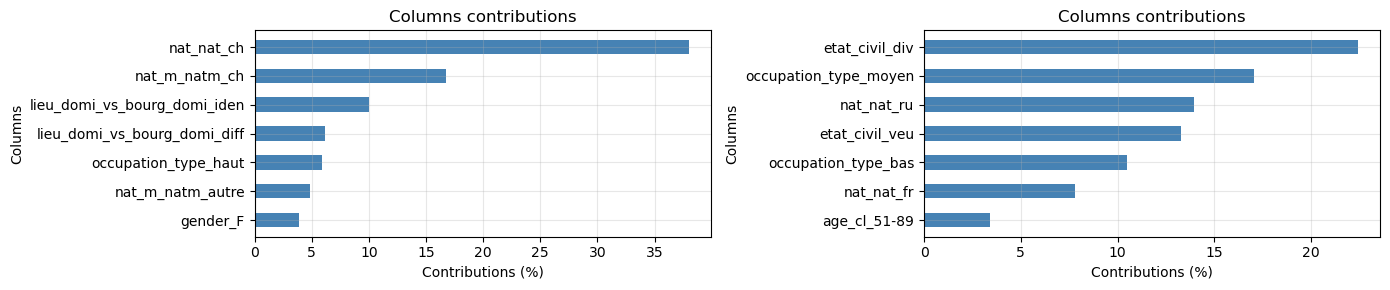

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14, 3))
acm.plot_col_contrib(num_axis=3,nb_values=7, ax = axes[0], short_labels=False)
acm.plot_col_contrib( num_axis=4,nb_values=7,ax = axes[1], short_labels=False)
plt.tight_layout()
plt.show()

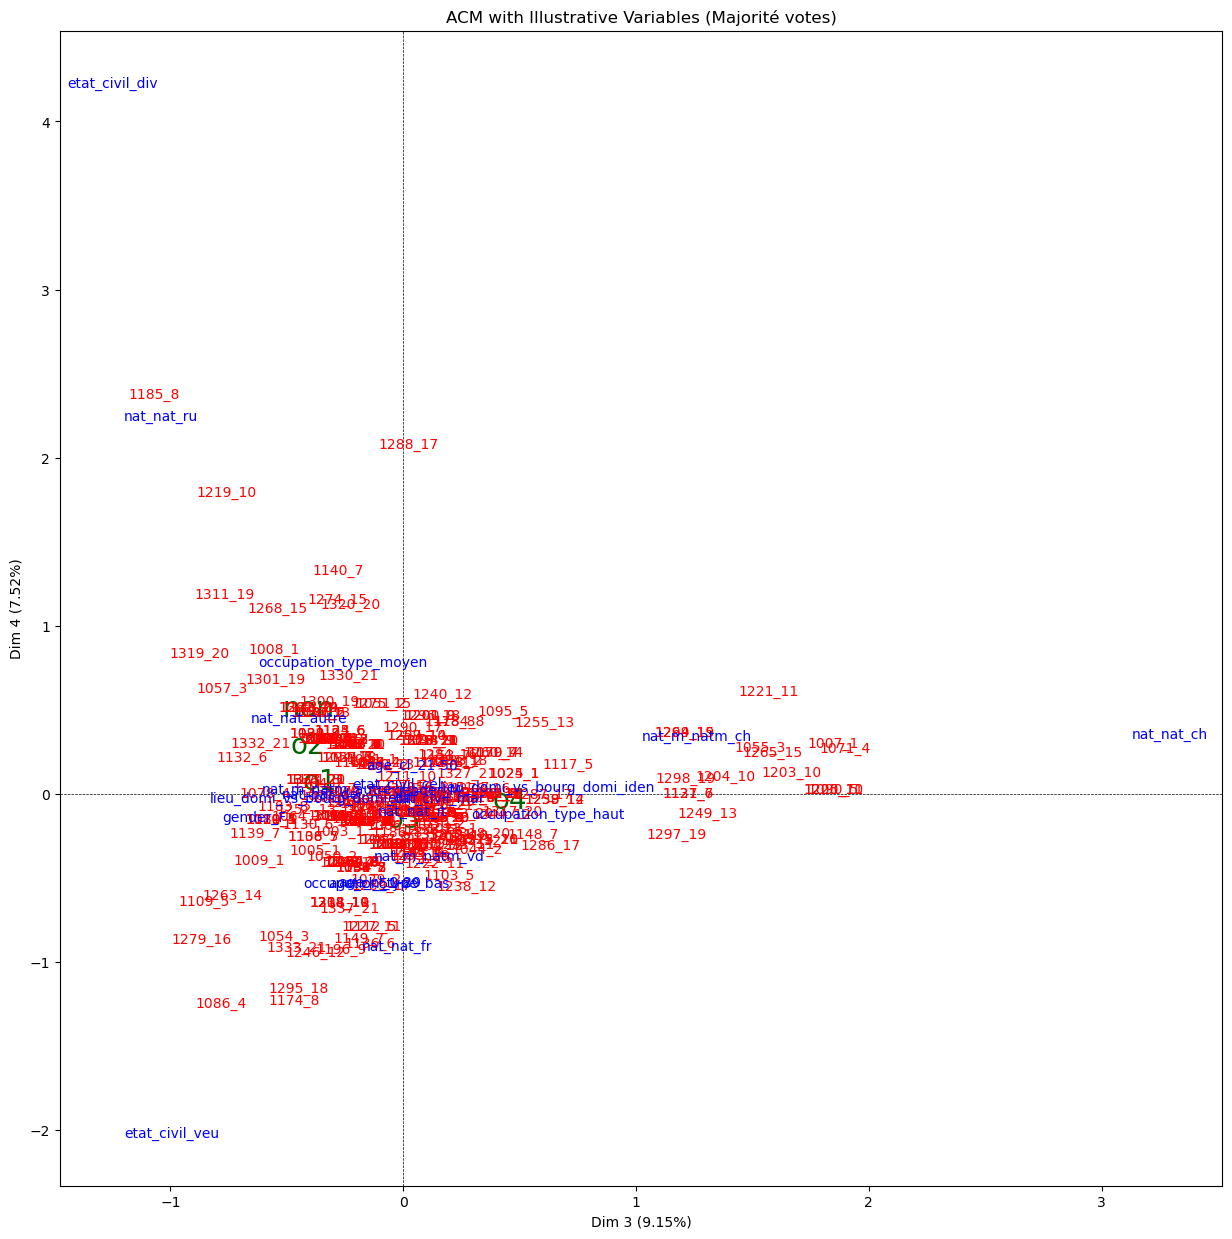

In [ ]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Plot ACM on ax
acm.mapping(num_x_axis=3, num_y_axis=4, ax=ax, short_labels=False)

# ✅ Add your additional layer BEFORE or AFTER

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Majorité votes)")
plt.show()
